In [2]:
%load_ext autoreload
# %autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch

import evoscape.landscape_visuals as vis
from evoscape.landscapes import Landscape
# from evoscape.landscapes.landscape_phase_analysis import LandscapePhaseAnalysisBase
from evoscape.modules import Node, Center, NegCenter, UnstableNode
from evoscape.morphogen_regimes import mr_const

plt.style.use("default")
plt.rcParams.update({"figure.dpi": 120})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from evoscape.landscape_visuals_config import (
    surface_contour_color,
    potential_surface_cmap,)

from matplotlib.colors import CenteredNorm


In [3]:
def PolynomialLandscape(Landscape):
    pass


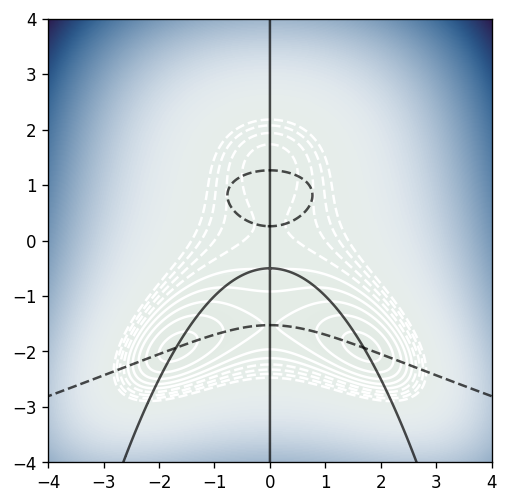

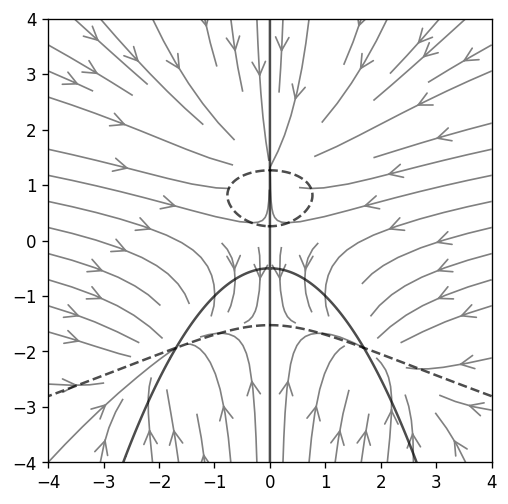

In [156]:
a1 = 1.
a2 = 1.
T2 = 1.5   # 1.5 for flip, 0


def phi(x,y, T, h1, h2):
    T1 = -1*y
    # T1 = -3*y

    return -h1*x - h2*y + a1*(T - T1)*x**2 + a2*(T - T2)*y**2 + x**4/4 + y**4/4

def flow(x,y, T, h1, h2):
    T1 = -1*y
    dT1dy = -1.

    # T1 = -3*y
    # dT1dy = -3.

    dX = h1 - 2*a1*(T-T1)*x - x**3
    dY = h2 - 2*a2*(T-T2)*y + a2*dT1dy*x**2 - y**3
    return dX, dY

L = 4
q = np.linspace(-L, L, 401)
xx, yy = np.meshgrid(q, q, indexing="xy")



T = 0.5 # 0.5 for flip, 2
h1 = 0. # vary
h2 = -0.5 # 0.5 for flip
potential = phi(xx, yy, T, h1, h2)
dX, dY = flow(xx, yy, T, h1, h2)

fig, ax = plt.subplots()
ax.imshow(potential, cmap=potential_surface_cmap, origin='lower', norm=CenteredNorm(5),
             extent=(np.min(xx), np.max(xx), np.min(yy), np.max(yy)))
ax.contour(xx, yy, -potential, origin='lower', colors=surface_contour_color, levels=np.linspace(-2, 3., 9))
ax.contour(xx, yy, dX, (0,), colors=('k',), linestyles='-', linewidths=1.5, alpha=0.7)
ax.contour(xx, yy, dY, (0,), colors=('k',), linestyles='--', linewidths=1.5, alpha=0.7)
plt.show()

fig, ax = plt.subplots()
ax.streamplot(xx, yy, dX, dY, density=0.6, arrowsize=2., arrowstyle='->', linewidth=1, color='grey')
ax.contour(xx, yy, dX, (0,), colors=('k',), linestyles='-', linewidths=1.5, alpha=0.7)
ax.contour(xx, yy, dY, (0,), colors=('k',), linestyles='--', linewidths=1.5, alpha=0.7)
ax.set_aspect('equal')
plt.show()

In [490]:
def update_landscape(p1, p2):
    sig=0.5
    s_head = sig * np.exp(+p2 / 2)
    s_fate = sig * np.exp(-p2 / 2)
    s_left = s_fate * np.exp(-p1 / 2)
    s_right = s_fate * np.exp(p1 / 2)

    x_fate = 1.5 #1.1, 1.5
    # y_cycle = 0.5 # 0.5
    modules = [
        Node(x=-0.0, y=0., a=4., s=s_head),
        Node(x=-x_fate, y=0., a=4.5, s=s_left+0.01),
        Node(x=+x_fate, y=0., a=4.5, s=s_right),
        # UnstableNode(x=0.0, y=0, a=6., s=s_head*0.8),
        # Center(x=0, y=0., a=4., s=s_head*0.85),
    ]
    return Landscape(modules, A0=0.05, x0=(0., 0.), regime=mr_const, n_regimes=1)

In [104]:
# pitchfork
def update_landscape(p1, p2):
    sig=0.5
    s_head = sig * np.exp(+p2 / 2)
    s_fate = sig * np.exp(-p2 / 2)
    s_left = sig * np.exp(-p1 / 2)
    s_right = sig * np.exp(p1 / 2)

    x_fate = 0.8 * np.exp(-p2/2)  # was 1
    y_cycle = 0.8
    y_fate = -1.
    modules = [
        Node(x=-0.0, y=y_cycle, a=4., s=s_head), # a = 5
        Node(x=-x_fate, y=y_fate, a=4.05, s=s_left),
        Node(x=+x_fate, y=y_fate, a=4., s=s_right), # a = 5
        Node(x=0.0, y=y_fate, a=1., s=1.5*s_fate), # s = 1.5*, a = 2
    ]
    return Landscape(modules, A0=0.05, x0=(0., -1.), regime=mr_const, n_regimes=1)

{'n_fp': 3, 'n_cycles': 0, 'objects': [{'id': 1, 'type': 'attractor', 'location': array([-1.07333359, -1.        ]), 'node_id': 1}, {'id': 2, 'type': 'attractor', 'location': array([ 1.07259917, -1.        ]), 'node_id': 2}, {'id': 2, 'type': 'saddle', 'location': array([-0.09094104, -0.99999972])}], 'unstable_connections': [{'connection': (2, 1), 'target_type': 'attractor'}, {'connection': (2, 2), 'target_type': 'attractor'}]}


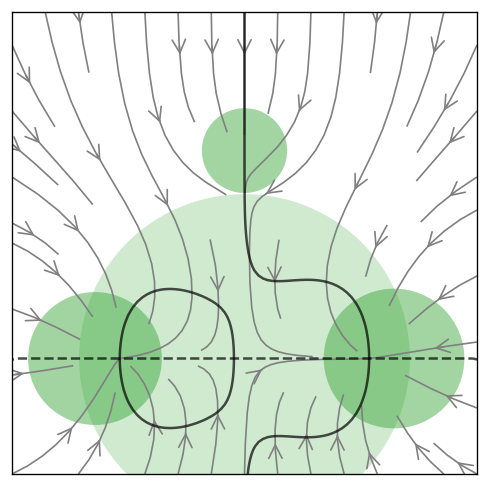

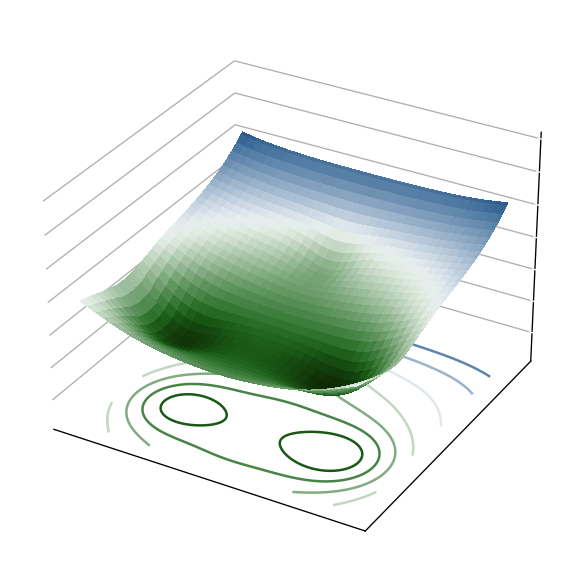

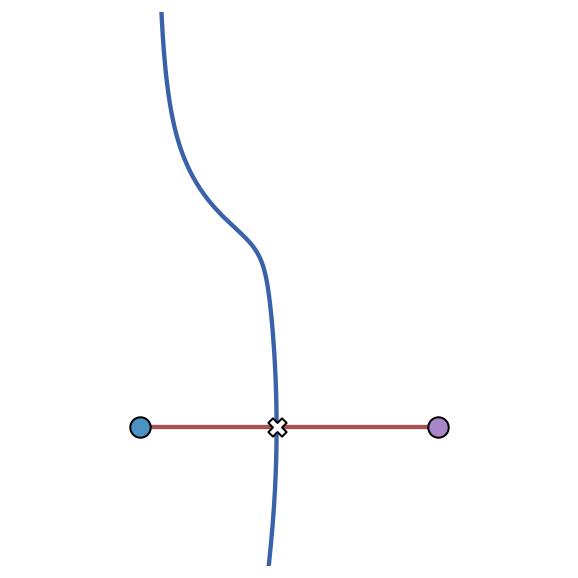

In [106]:
# q = np.linspace(-1.5, 1.5, 101)
# xx, yy = np.meshgrid(q+0.5, q+0.5, indexing="xy")

q = np.linspace(-2., 2., 101)
xx, yy = np.meshgrid(q, q, indexing="xy")

landscape = update_landscape(0.05, -0.95)

fig = vis.visualize_landscape(landscape, xx, yy, 0.,)
fig = vis.visualize_potential(landscape, xx, yy, 0., rot_contour=0)
phase_result = landscape.find_phase_objects_manifold(
    0.0,
    xx,
    yy,
    dt=0.1,
    n_steps=3000,
    cycle_window=1000,
)
catastrophe_info = landscape.get_catastrophe_info(phase_result)
print(catastrophe_info)

fig, ax, _ = vis.plot_phase_skeleton_t(
    landscape,
    xx,
    yy,
    0.0,
    phase_result=phase_result,
    show_saddle_manifolds=True,
    plot_stable_manifolds=True,
    module_order_colors=('tab:green', 'tab:blue', 'tab:purple'),
    basin_coloring='module',

    )

In [3]:
# s_left_range = (0.5, 1.2)
# s_right_range = (0.5, 1.2)
#
# def update_landscape(p1, p2):
#     s_left = s_left_range[0] + p1 * (s_left_range[1] - s_left_range[0])+0.01
#     s_right = s_right_range[0] + p2 * (s_right_range[1] - s_right_range[0])
#
#     modules = [
#         Node(x=-0.0, y=1.5, a=1.5, s=0.9),
#         Node(x=-1.1, y=-1.0, a=1.5, s=s_left),
#         Node(x=+1.1, y=-1.0, a=1.5, s=s_right),
#     ]
#     return Landscape(modules, A0=0.05, regime=mr_const, n_regimes=1)

In [249]:
# with amplitude - difficult to get SNs

# left_range = (0.5, 10.)
# right_range = (0.5, 10.)
#
# def update_landscape(p1, p2):
#     a_left = left_range[0] + p1 * (left_range[1] - left_range[0])+0.01
#     a_right = right_range[0] + p2 * (right_range[1] - right_range[0])
#
#     modules = [
#         Node(x=-0.0, y=1.5, a=1.5, s=0.9),
#         Node(x=-1.1, y=-1.0, a=a_left, s=0.8),
#         Node(x=+1.1, y=-1.0, a=a_right, s=0.8),
#     ]
#     return Landscape(modules, A0=0.05, regime=mr_const, n_regimes=1)

In [262]:
# %autoreload

In [267]:
# q = np.linspace(-2, 2, 101)
# xx, yy = np.meshgrid(q, q, indexing="xy")
#
# landscape = update_landscape(0.2, 0.8)
# fig = vis.visualize_landscape(landscape, xx, yy, 0.,)
# phase_result = landscape.find_phase_objects_manifold(
#     0.0,
#     xx,
#     yy,
#     dt=0.1,
#     n_steps=2000,
#     cycle_window=0,
# )
# catastrophe_info = landscape.get_catastrophe_info(phase_result)
# print(catastrophe_info)
#
# fig, ax, _ = vis.plot_phase_skeleton_t(
#     landscape,
#     xx,
#     yy,
#     0.0,
#     phase_result=phase_result,
#     show_saddle_manifolds=True,
#     )

In [268]:
# # with a and s ratios (theta = log ratio)
# a_range = (0.5, 10.)
# amp = np.sqrt(a_range[0]*a_range[1])
# s_range = (0.3, 1.5)
# sig = np.sqrt(s_range[0]*s_range[1])
#
# def update_landscape(p1, p2):
#
#     a_left = amp*np.exp(p1/2) + 0.01
#     a_right = amp*np.exp(-p1/2)
#     s_left = sig*np.exp(p2/2) +0.01
#     s_right = sig*np.exp(-p2/2)
#
#     modules = [
#         Node(x=-0.0, y=1.5, a=1.5, s=0.9),
#         Node(x=-1.1, y=-1.0, a=a_left, s=s_left),
#         Node(x=+1.1, y=-1.0, a=a_right, s=s_right),
#     ]
#     return Landscape(modules, A0=0.05, regime=mr_const, n_regimes=1)

In [271]:
# # with head attractor amp and s ratios (p1 = log ratio)
# a_range = (0.1, 5.)
# amp = np.sqrt(a_range[0]*a_range[1])
# s_range = (0.1, 1.5)
# sig = np.sqrt(s_range[0]*s_range[1])
#
# def update_landscape(p1, p2):
#
#     # a_top = amp*np.exp(p2/2)
#     # a_bottom = amp*np.exp(-p2/2)
#     a_top = 3.
#     a_bottom = 3.
#     # sig = 0.2*np.exp(-p2/2)
#     s_top = sig*np.exp(p2/2)
#     s_bottom = sig*np.exp(-p2/2)
#     s_left = s_bottom*np.exp(-p1/2)
#     s_right = s_bottom*np.exp(p1/2)
#
#     modules = [
#         Node(x=-0.0, y=1.5, a=a_top, s=s_top),
#         Node(x=-1.1, y=-1.0, a=a_bottom, s=s_left+0.01),
#         Node(x=+1.1, y=-1.0, a=a_bottom, s=s_right),
#     ]
#     return Landscape(modules, A0=0.05, regime=mr_const, n_regimes=1)

In [56]:
# with oscillator and s ratios (p1 = log ratio)

# a_range = (0.1, 5.)
# amp = np.sqrt(a_range[0]*a_range[1])
s_range = (0.1, 0.5)
sig = np.sqrt(s_range[0]*s_range[1])

def update_landscape(p1, p2):

    # a_top = amp*np.exp(p2/2)
    # a_bottom = amp*np.exp(-p2/2)
    # a_top = 3.
    # a_bottom = 3.
    # sig = 0.3
    s_head = sig*np.exp(+p2/2)
    s_fate = sig*np.exp(-p2/2)
    s_left = s_fate*np.exp(-p1/2)
    s_right = s_fate*np.exp(p1/2)

    modules = [
        Node(x=0., y=0., a=7., s=s_head),
        Node(x=0., y=1., a=3., s=s_left),
        Node(x=1., y=0., a=3., s=s_right),
        Node(x=0.5, y=0.6, a=0.5, s=0.3),
        Center(x=0, y=0, a=3., s=s_head*1.01), # s=0.3, a=5
        UnstableNode(x=0, y=0, a=8., s=s_head*0.8)
    ]
    return Landscape(modules, A0=0.05, regime=mr_const, n_regimes=1)

In [327]:
# # with oscillator and s ratios (p1 = log ratio)
#
# # a_range = (0.1, 5.)
# # amp = np.sqrt(a_range[0]*a_range[1])
# s_range = (0.1, 0.8)
# sig = np.sqrt(s_range[0]*s_range[1])
#
# def update_landscape(p1, p2):
#
#     # a_top = amp*np.exp(p2/2)
#     # a_bottom = amp*np.exp(-p2/2)
#     # a_top = 3.
#     # a_bottom = 3.
#     sig = 0.6
#     s_head = sig*np.exp(p2/2)
#     s_fate = sig*np.exp(-p2/2)
#     s_left = s_fate*np.exp(-p1/2)
#     s_right = s_fate*np.exp(p1/2)
#
#     print(s_head, s_left, s_right)
#
#     modules = [
#         Node(x=-0.0, y=1., a=7., s=s_head),
#
#         Node(x=-1.1, y=-1.0, a=5., s=s_left),
#         Node(x=+1.1, y=-1.0, a=5., s=s_right+0.01),
#
#         UnstableNode(x=0.0, y=1., a=10., s=s_head*0.6),
#         Center(x=0, y=1., a=3., s=s_head*0.7),
#         # Node(x=0., y=-0.8, a=0.5, s=0.5),
#
#     ]
#     return Landscape(modules, A0=0.05, x0=(0., -0.5), regime=mr_const, n_regimes=1)

In [451]:
# with oscillator and s ratios (p1 = log ratio)

# a_range = (0.1, 5.)
# amp = np.sqrt(a_range[0]*a_range[1])
# a_range = (1., 5.)
amp = np.sqrt(a_range[0]*a_range[1])

def update_landscape(p1, p2):

    # a_top = amp*np.exp(p2/2)
    # a_bottom = amp*np.exp(-p2/2)
    # a_top = 3.
    # a_bottom = 3.
    # sig = 0.6
    amp = 4.
    a_head = amp*np.exp(p2/2)
    a_fate = amp*np.exp(-p2/2)
    a_left = amp*np.exp(-p1/2)
    a_right = amp*np.exp(p1/2)

    print(a_head, a_left, a_right)

    modules = [
        Node(x=-0.0, y=0.8, a=4., s=0.8),

        Node(x=-1.1, y=-1., a=a_left, s=0.75+0.01),
        Node(x=+1.1, y=-1., a=a_right, s=0.75),

        UnstableNode(x=0.0, y=0.8, a=a_head*2, s=0.4),
        Center(x=0, y=.8, a=3., s=0.7), # or a_head

        # Node(x=0., y=-0.8, a=0.5, s=0.5),

    ]
    return Landscape(modules, A0=0.05, x0=(0., -0.8), regime=mr_const, n_regimes=1)

5.399435230304013 5.399435230304013 2.9632728827268715
{'n_fp': 5, 'n_cycles': 1, 'objects': [{'id': 1, 'type': 'attractor', 'location': array([-1.02415711, -0.95705678]), 'node_id': 1}, {'id': 2, 'type': 'attractor', 'location': array([ 0.94791921, -0.84325488]), 'node_id': 2}, {'id': 0, 'type': 'cycle', 'location': array([0.14596395, 0.32847295]), 'radius': 0.7055770441725928, 'period': 28.900000000000002, 'node_id': 0}, {'id': 3, 'type': 'saddle', 'location': array([-0.08795896, -0.40224762])}, {'id': 4, 'type': 'saddle', 'location': array([ 0.79598296, -0.31451151])}], 'unstable_connections': [{'connection': (3, 1), 'target_type': 'attractor'}, {'connection': (3, 0), 'target_type': 'cycle'}, {'connection': (4, 0), 'target_type': 'cycle'}, {'connection': (4, 2), 'target_type': 'attractor'}]}


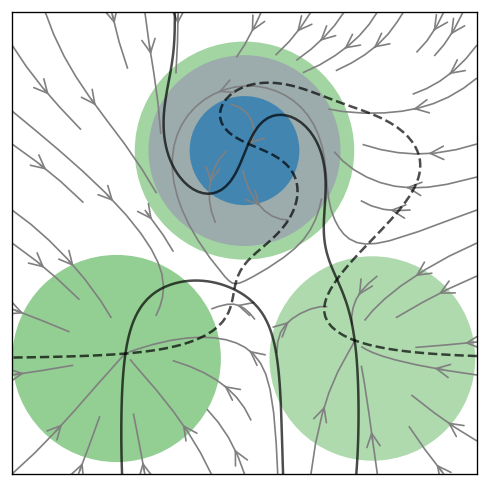

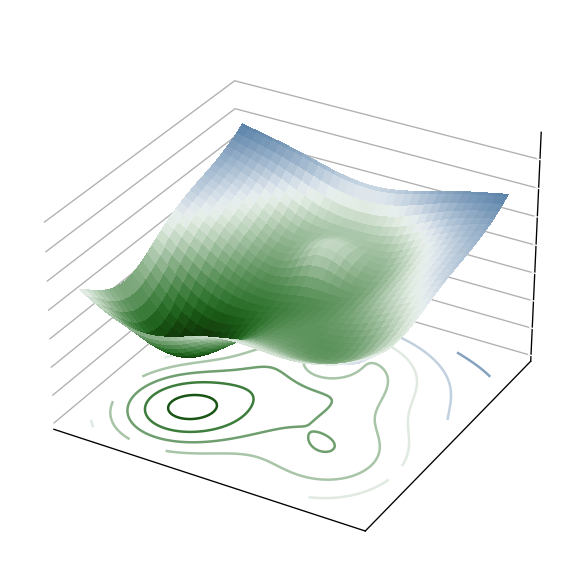

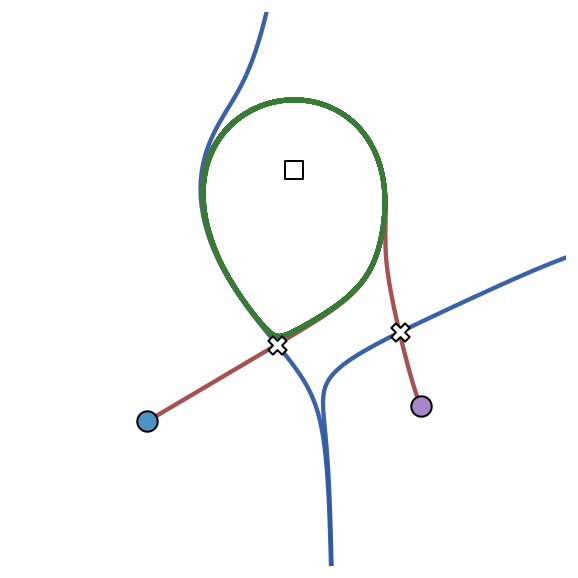

In [460]:
# q = np.linspace(-1.5, 1.5, 101)
# xx, yy = np.meshgrid(q+0.5, q+0.5, indexing="xy")

q = np.linspace(-2., 2., 101)
xx, yy = np.meshgrid(q, q, indexing="xy")

landscape = update_landscape(-0.6, 0.6)
fig = vis.visualize_landscape(landscape, xx, yy, 0.,)
fig = vis.visualize_potential(landscape, xx, yy, 0., rot_contour=0)
phase_result = landscape.find_phase_objects_manifold(
    0.0,
    xx,
    yy,
    dt=0.1,
    n_steps=3000,
    cycle_window=1000,
)
catastrophe_info = landscape.get_catastrophe_info(phase_result)
print(catastrophe_info)

fig, ax, _ = vis.plot_phase_skeleton_t(
    landscape,
    xx,
    yy,
    0.0,
    phase_result=phase_result,
    show_saddle_manifolds=True,
    plot_stable_manifolds=True,
    module_order_colors=('tab:green', 'tab:blue', 'tab:purple'),
    basin_coloring='module',

    )

In [129]:
# n_grid_points = 11
# p1 = np.linspace(0.0, 1.0, n_grid_points)
# p2 = np.linspace(0.0, 1.0, n_grid_points)


# n_grid_points = 21
# p1 = np.linspace(-2.0, 2.0, n_grid_points)
# p2 = np.linspace(-2.0, 2.0, n_grid_points)


n_grid_points = 11
p1 = np.linspace(-1, 2, n_grid_points)
p2 = np.linspace(-0.5, 1, n_grid_points)
q = np.linspace(-1.5, 1.5, 101)
xx, yy = np.meshgrid(q+0.5, q+0.5, indexing="xy")

P1, P2 = np.meshgrid(p1, p2, indexing="xy")

n_fp_grid = np.zeros((len(p2), len(p1)), dtype=int)
catastrophe_info_grid = np.empty((len(p2), len(p1)), dtype=object)



# q = np.linspace(-2.0, 2.0, 101)
# xx, yy = np.meshgrid(q, q, indexing="xy")


# q_vis = np.linspace(-3.0, 3.0, 101)
# xx_vis, yy_vis = np.meshgrid(q_vis, q_vis, indexing="xy")

def unstable_connection_signature(catastrophe_info):
    return tuple(
        sorted(
            (
                int(connection["connection"][0]),
                int(connection["connection"][1]),
                str(connection["target_type"]),
            )
            for connection in catastrophe_info["unstable_connections"]
        )
    )

def signature_label(signature):
    if not signature:
        return "no unstable connections"
    return "; ".join(f"{src}->{dst} ({target_type})" for src, dst, target_type in signature)

def mix_with_white(color, amount):
    rgb = np.asarray(to_rgb(color), dtype=float)
    return tuple((1.0 - amount) * rgb + amount * np.ones(3, dtype=float))

In [276]:
total_points = len(p1) * len(p2)

for row_index, p2_value in enumerate(p2):
    print(f"Computing row {row_index + 1}/{len(p2)}")
    for col_index, p1_value in enumerate(p1):
        landscape = update_landscape(p1_value, p2_value)
        phase_result = landscape.find_phase_objects_manifold(
            0.0,
            xx,
            yy,
            dt=0.2,
            n_steps=10000,
            cycle_window=2000,
        )
        catastrophe_info = landscape.get_catastrophe_info(phase_result)
        catastrophe_info_grid[row_index, col_index] = catastrophe_info
        n_fp_grid[row_index, col_index] = catastrophe_info["n_fp"]

print("Unique fixed-point counts:", np.unique(n_fp_grid).tolist())

Computing row 1/11
Computing row 2/11
Computing row 3/11
Computing row 4/11
Computing row 5/11
Computing row 6/11
Computing row 7/11
Computing row 8/11
Computing row 9/11
Computing row 10/11
Computing row 11/11
Unique fixed-point counts: [1, 2, 3, 4, 5, 6]


In [277]:
unique_n_fp = sorted(np.unique(n_fp_grid).tolist())

base_cmap = plt.get_cmap("Accent")
base_colors = {
    int(n_fp): base_cmap(idx)[:3]
    for idx, n_fp in enumerate(unique_n_fp)
}

region_indices = {}
for row_index in range(len(p2)):
    for col_index in range(len(p1)):
        catastrophe_info = catastrophe_info_grid[row_index, col_index]
        key = (
            int(catastrophe_info["n_fp"]),
            unstable_connection_signature(catastrophe_info),
        )
        region_indices.setdefault(key, []).append((row_index, col_index))

region_color_map = {}
region_summary = []
rgba_grid = np.zeros((len(p2), len(p1), 4), dtype=float)

for n_fp in unique_n_fp:
    signatures = sorted(
        {signature for (fp_value, signature) in region_indices if fp_value == n_fp},
        key=str,
    )
    shade_amounts = np.array([0.0]) if len(signatures) == 1 else np.linspace(0.0, 0.8, len(signatures))

    for signature_index, (signature, shade_amount) in enumerate(zip(signatures, shade_amounts)):
        key = (int(n_fp), signature)
        region_color_map[key] = mix_with_white(base_colors[int(n_fp)], float(shade_amount))
        region_summary.append(
            {
                "n_fp": int(n_fp),
                "signature": signature,
                "signature_index": int(signature_index),
                "n_signatures": int(len(signatures)),
                "n_cells": int(len(region_indices[key])),
            }
        )

for row_index in range(len(p2)):
    for col_index in range(len(p1)):
        catastrophe_info = catastrophe_info_grid[row_index, col_index]
        key = (
            int(catastrophe_info["n_fp"]),
            unstable_connection_signature(catastrophe_info),
        )
        rgba_grid[row_index, col_index, :3] = region_color_map[key]
        rgba_grid[row_index, col_index, 3] = 1.0

for entry in sorted(region_summary, key=lambda item: (item["n_fp"], str(item["signature"]))):
    print(
        f"n_fp={entry['n_fp']}, variant {entry['signature_index'] + 1}/{entry['n_signatures']}, "
        f"cells={entry['n_cells']}, unstable_connections={signature_label(entry['signature'])}"
    )

n_fp=1, variant 1/1, cells=4, unstable_connections=no unstable connections
n_fp=2, variant 1/1, cells=1, unstable_connections=1->-1 (None); 1->0 (cycle)
n_fp=3, variant 1/5, cells=3, unstable_connections=1->-1 (None); 1->0 (cycle); 2->-1 (None); 2->0 (cycle)
n_fp=3, variant 2/5, cells=2, unstable_connections=1->1 (attractor); 1->1 (attractor)
n_fp=3, variant 3/5, cells=20, unstable_connections=1->2 (attractor); 1->2 (attractor)
n_fp=3, variant 4/5, cells=3, unstable_connections=2->0 (cycle); 2->1 (attractor)
n_fp=3, variant 5/5, cells=1, unstable_connections=2->0 (cycle); 2->2 (attractor)
n_fp=4, variant 1/9, cells=2, unstable_connections=1->-1 (None); 1->2 (attractor); 2->-1 (None); 2->2 (attractor)
n_fp=4, variant 2/9, cells=11, unstable_connections=1->-1 (None); 1->2 (attractor); 2->2 (attractor); 2->2 (attractor)
n_fp=4, variant 3/9, cells=7, unstable_connections=1->1 (attractor); 1->1 (attractor); 2->-1 (None); 2->1 (attractor)
n_fp=4, variant 4/9, cells=2, unstable_connections=2-

/Users/victoria/Code/evoscape/src/evoscape/landscape_visuals.py:98: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, stream_ax = plt.subplots(1, 1, figsize=(5, 5))


[{'n_fp': 1, 'signature': (), 'p1': 2.0, 'p2': -0.2, 'n_cells': 4},
 {'n_fp': 2,
  'signature': ((1, -1, 'None'), (1, 0, 'cycle')),
  'p1': 0.5,
  'p2': 1.0,
  'n_cells': 1},
 {'n_fp': 3,
  'signature': ((1, -1, 'None'),
   (1, 0, 'cycle'),
   (2, -1, 'None'),
   (2, 0, 'cycle')),
  'p1': 0.19999999999999996,
  'p2': 0.7,
  'n_cells': 3},
 {'n_fp': 3,
  'signature': ((1, 1, 'attractor'), (1, 1, 'attractor')),
  'p1': -1.0,
  'p2': 1.0,
  'n_cells': 2},
 {'n_fp': 3,
  'signature': ((1, 2, 'attractor'), (1, 2, 'attractor')),
  'p1': 2.0,
  'p2': -0.050000000000000044,
  'n_cells': 20},
 {'n_fp': 3,
  'signature': ((2, 0, 'cycle'), (2, 1, 'attractor')),
  'p1': -0.7,
  'p2': 0.8499999999999999,
  'n_cells': 3},
 {'n_fp': 3,
  'signature': ((2, 0, 'cycle'), (2, 2, 'attractor')),
  'p1': 0.7999999999999998,
  'p2': 1.0,
  'n_cells': 1},
 {'n_fp': 4,
  'signature': ((1, -1, 'None'),
   (1, 2, 'attractor'),
   (2, -1, 'None'),
   (2, 2, 'attractor')),
  'p1': 0.7999999999999998,
  'p2': -0.35

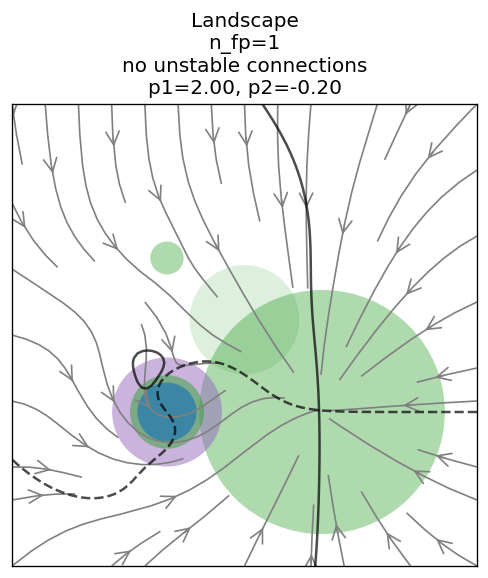

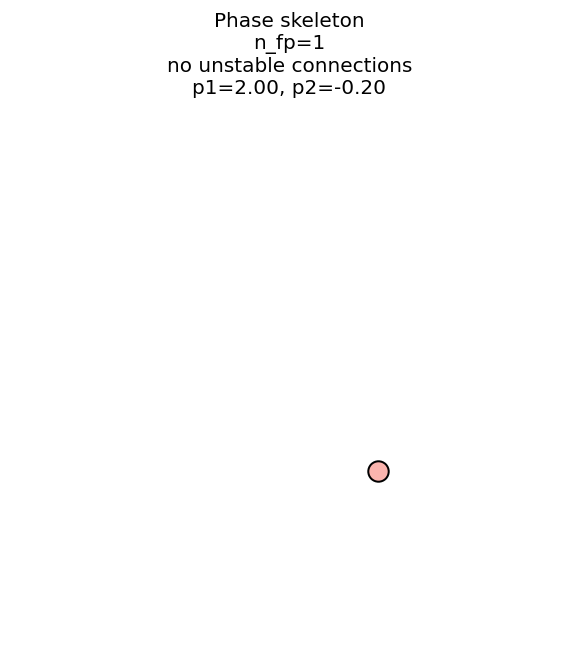

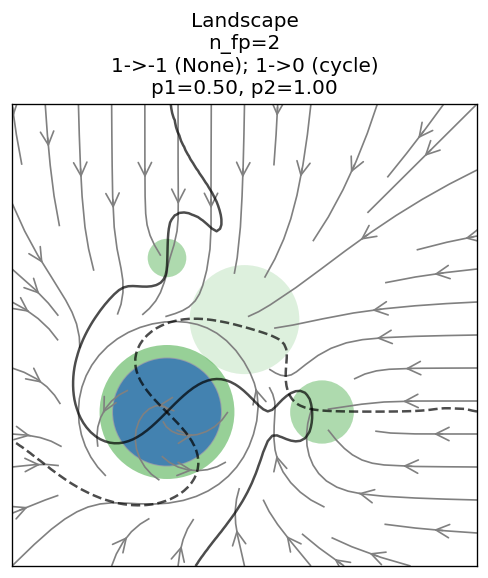

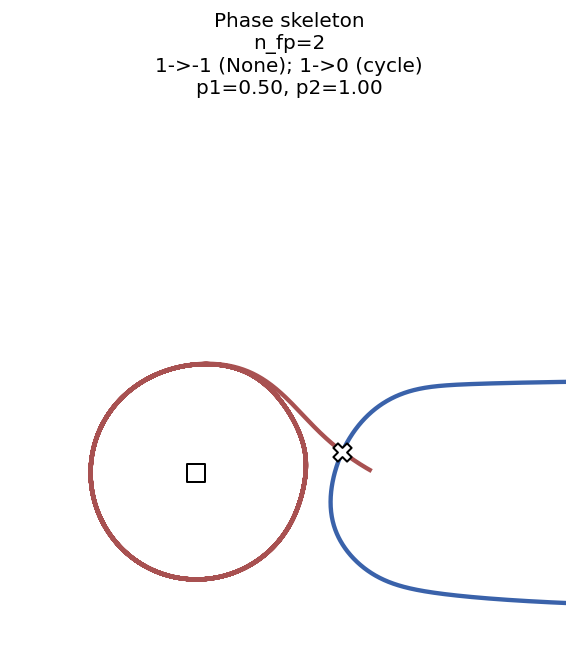

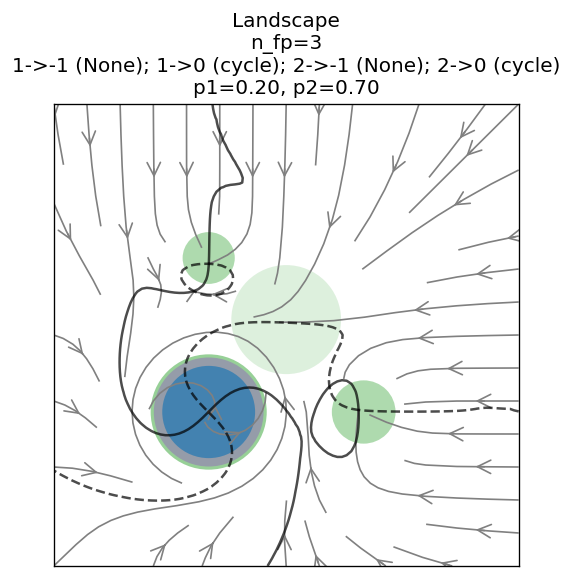

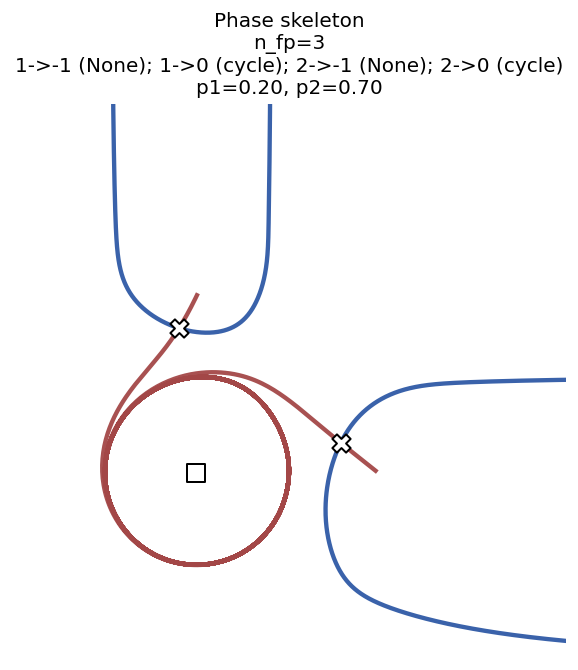

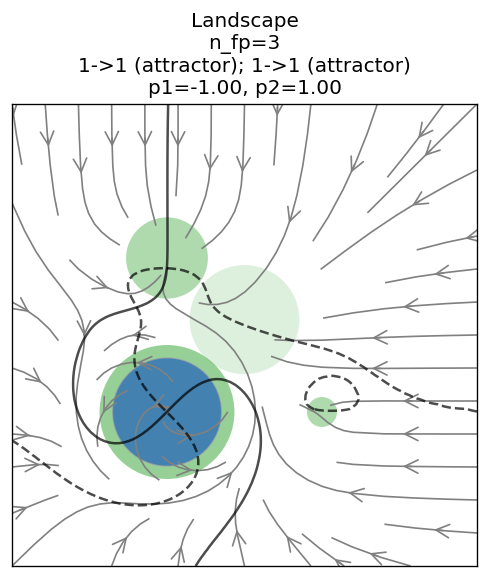

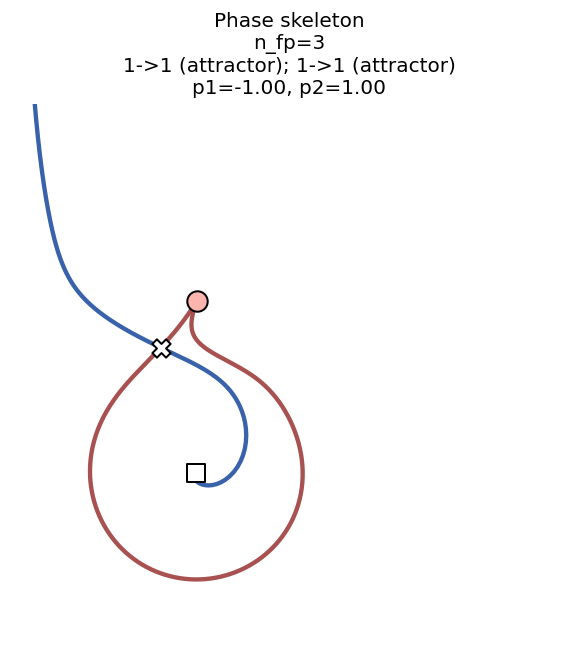

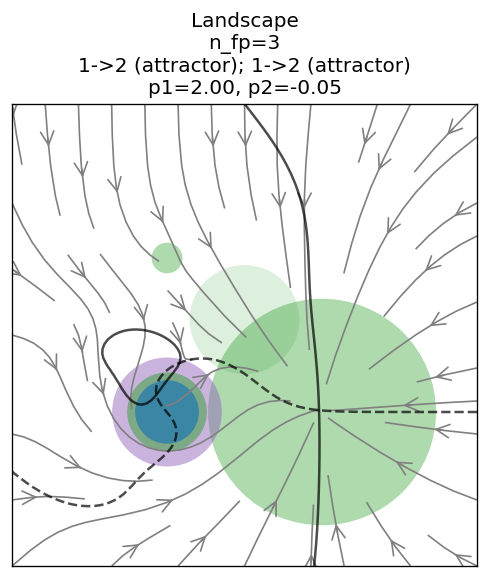

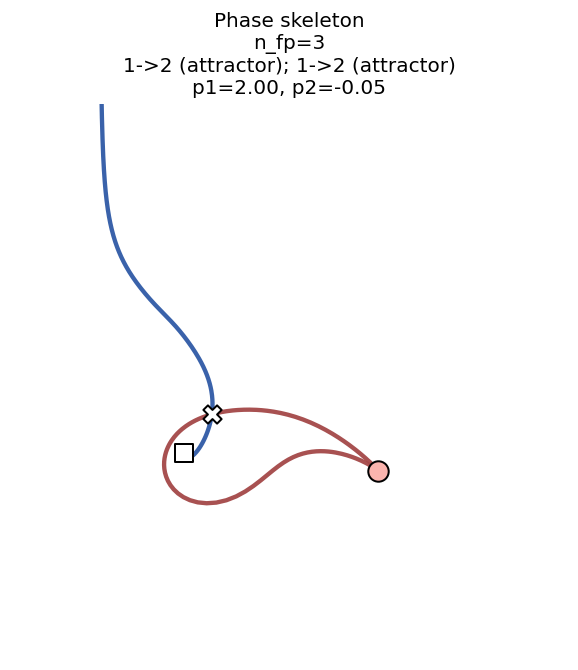

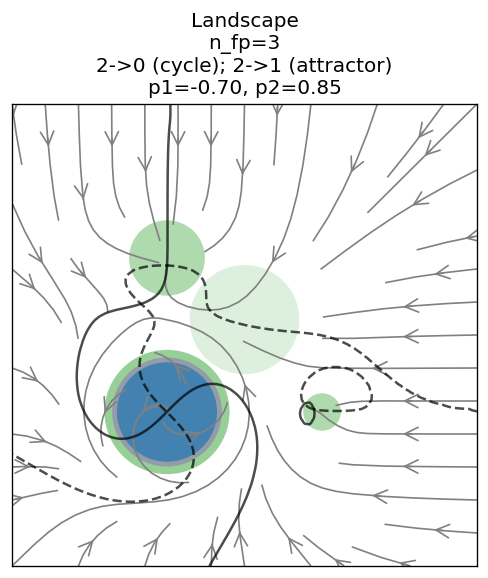

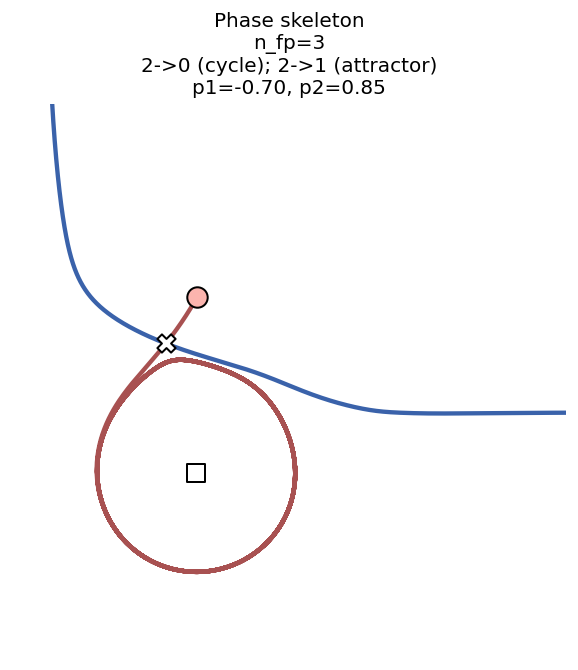

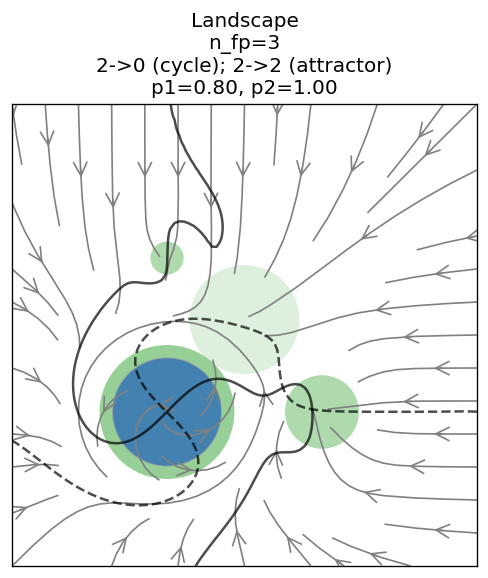

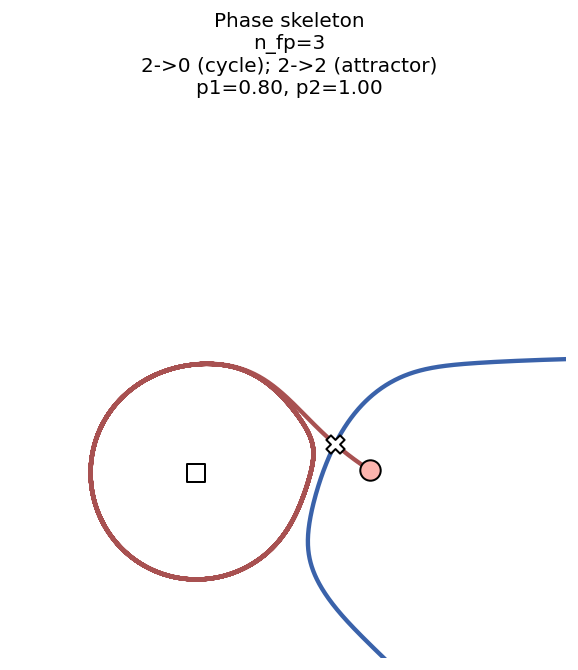

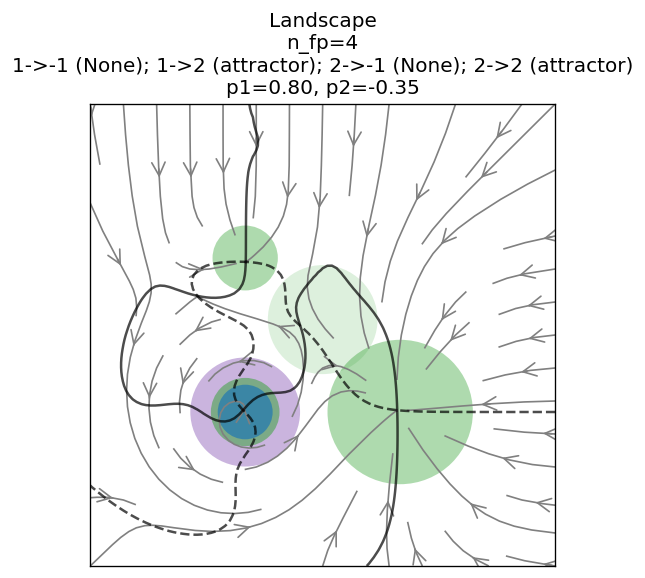

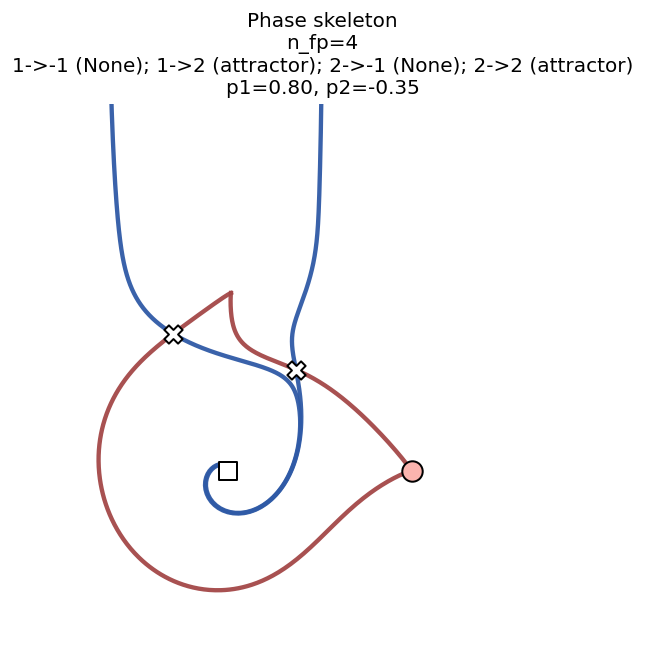

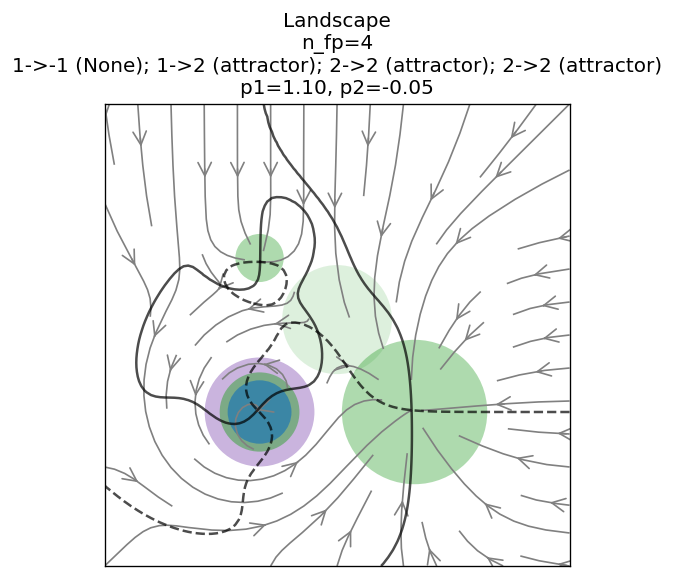

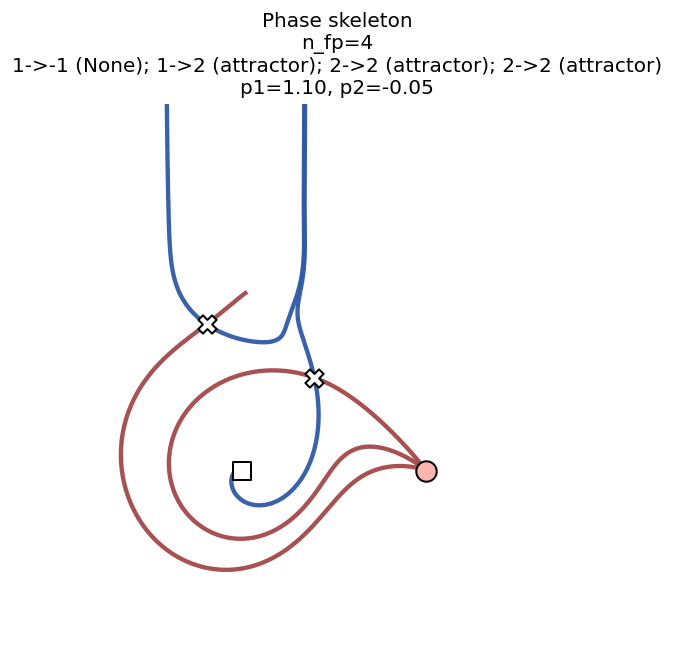

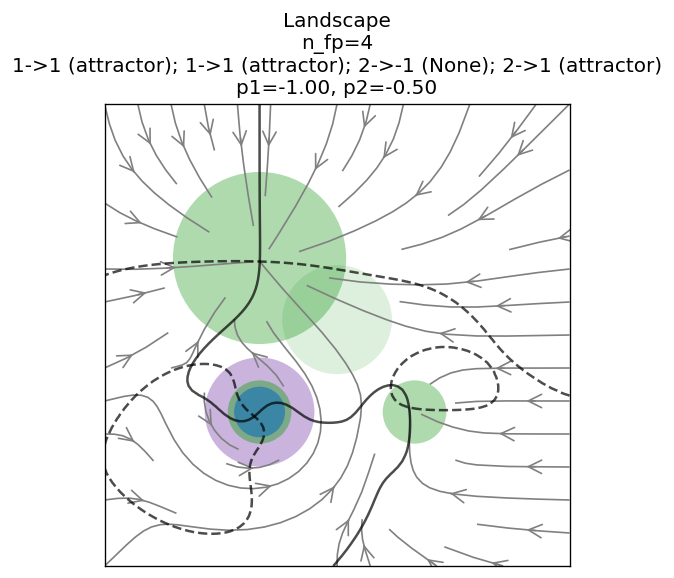

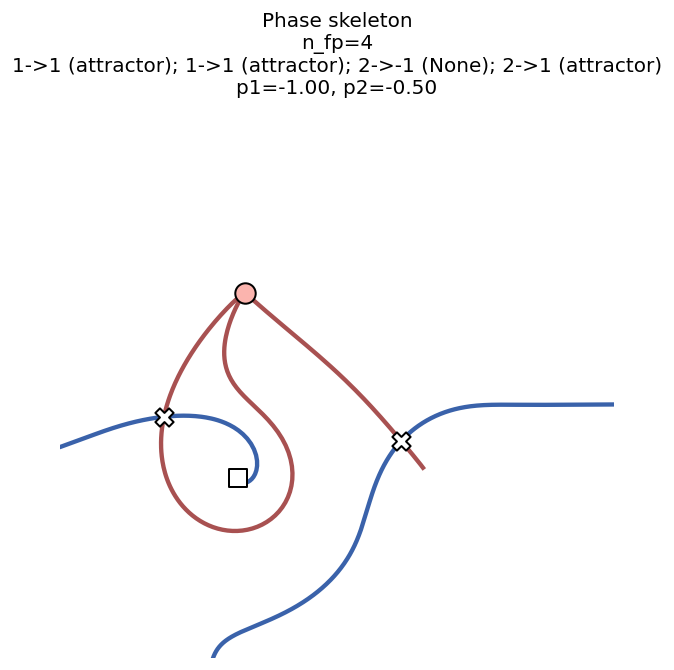

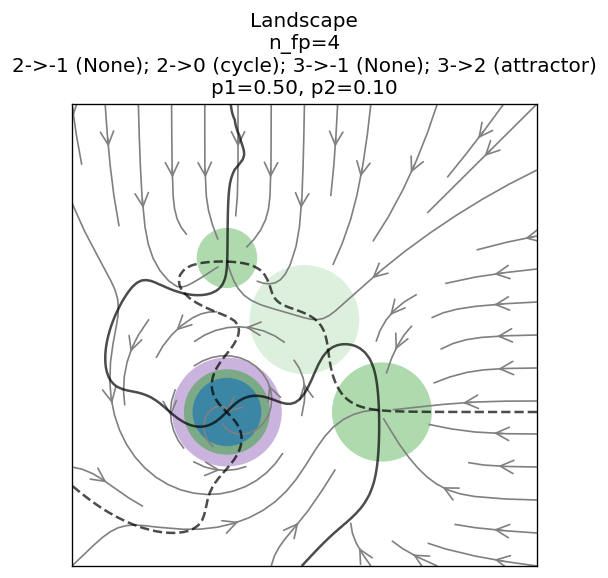

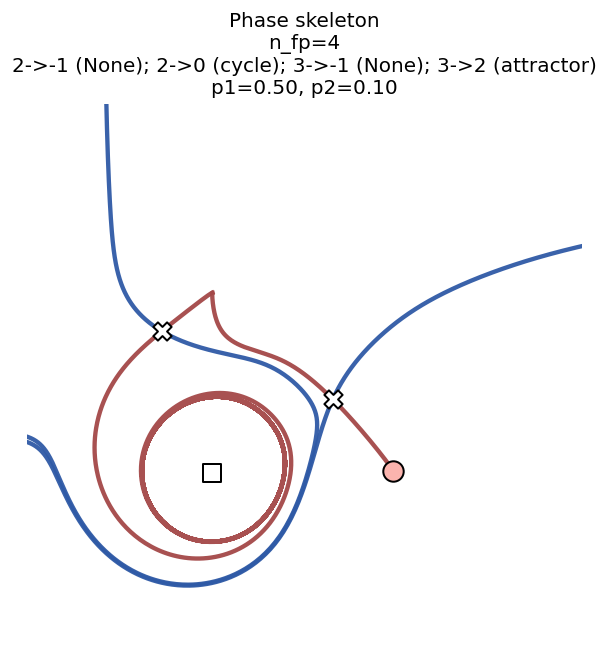

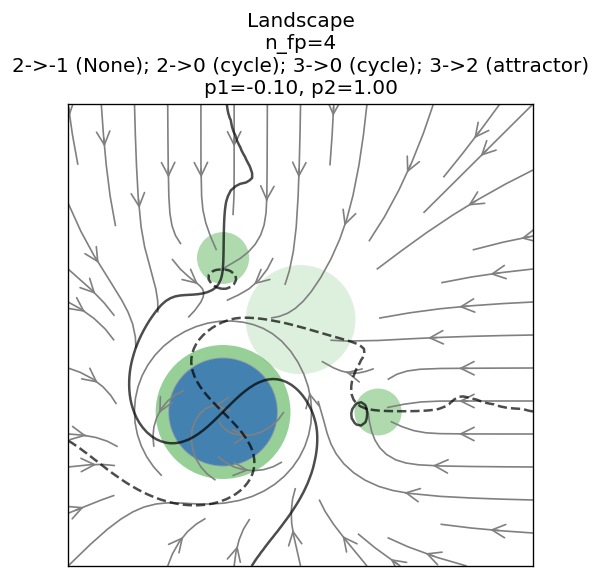

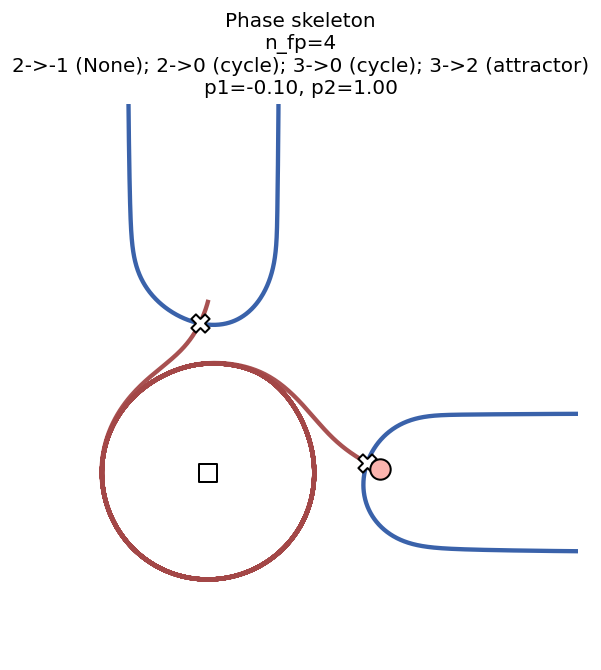

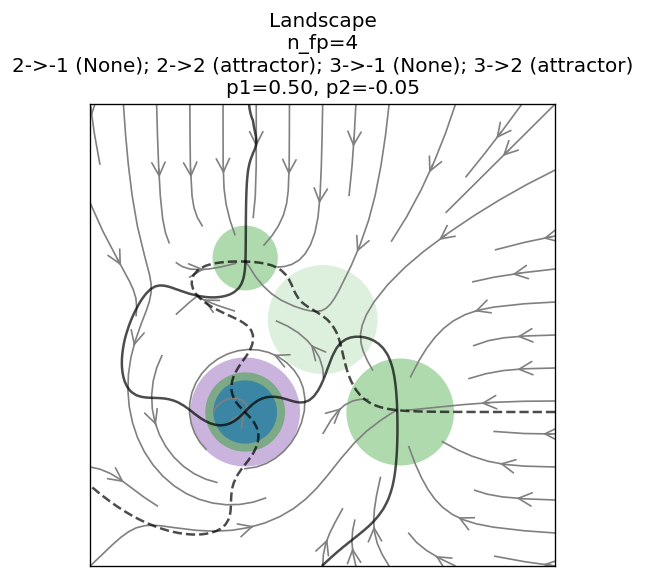

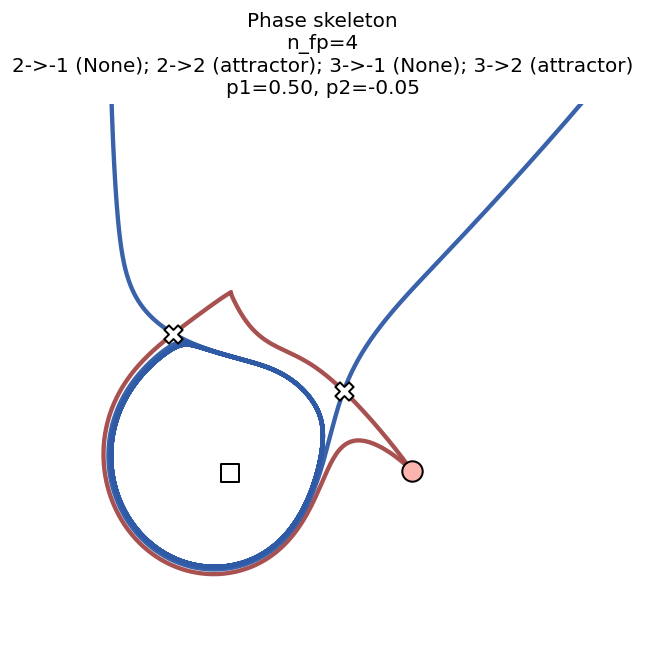

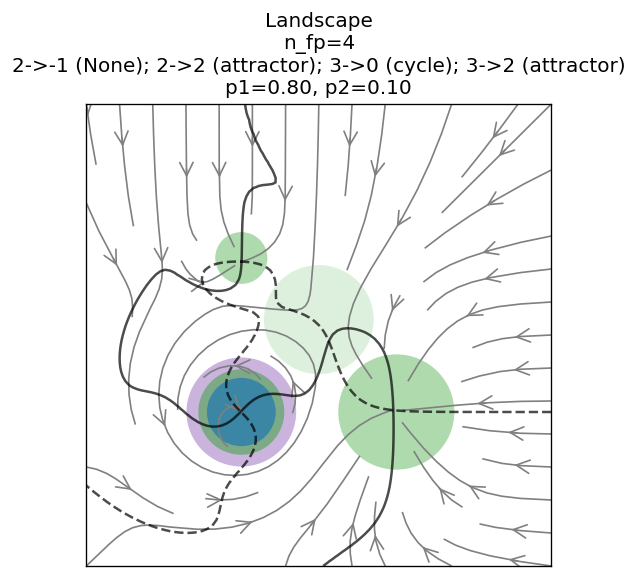

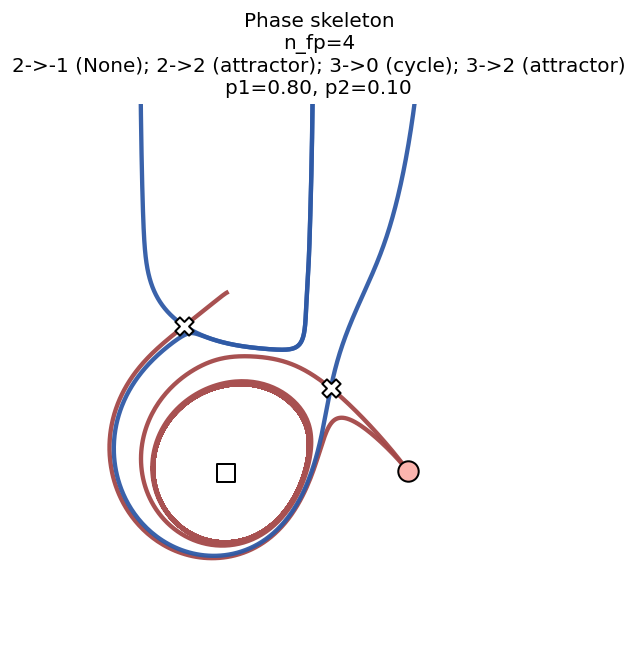

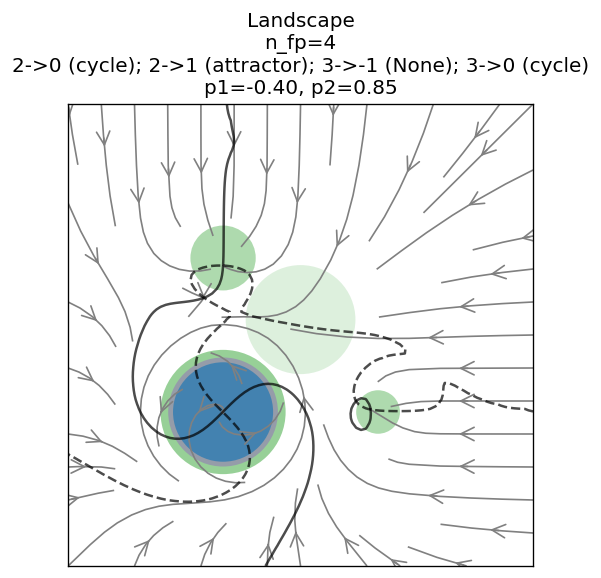

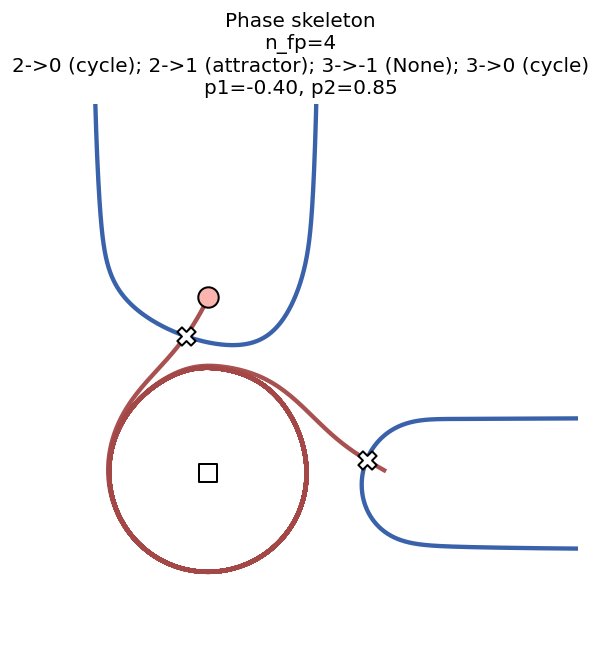

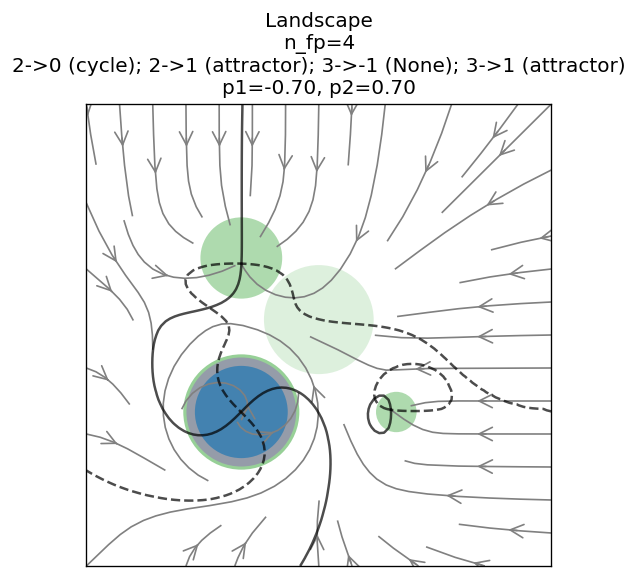

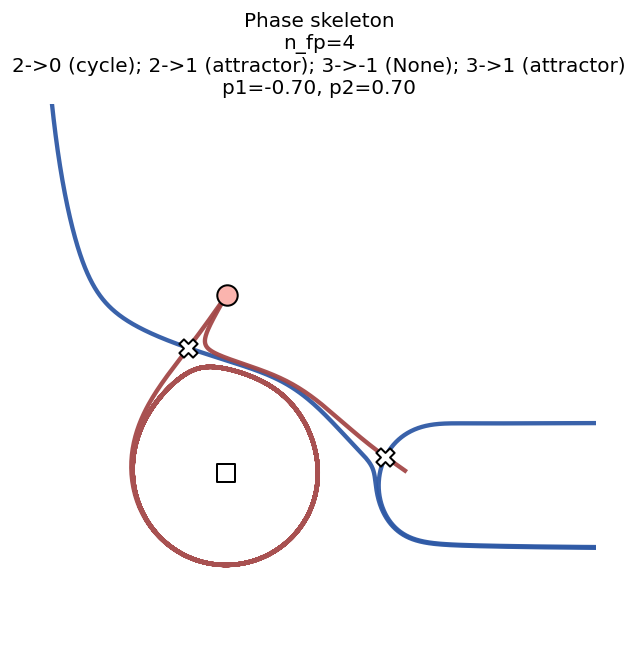

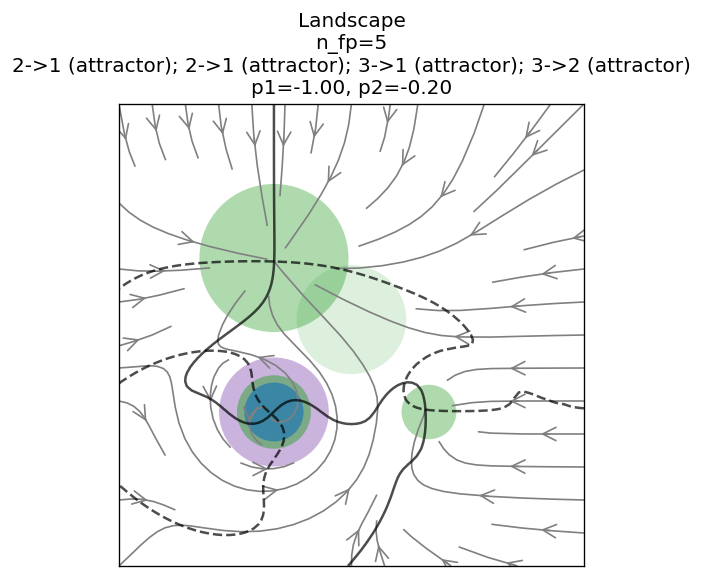

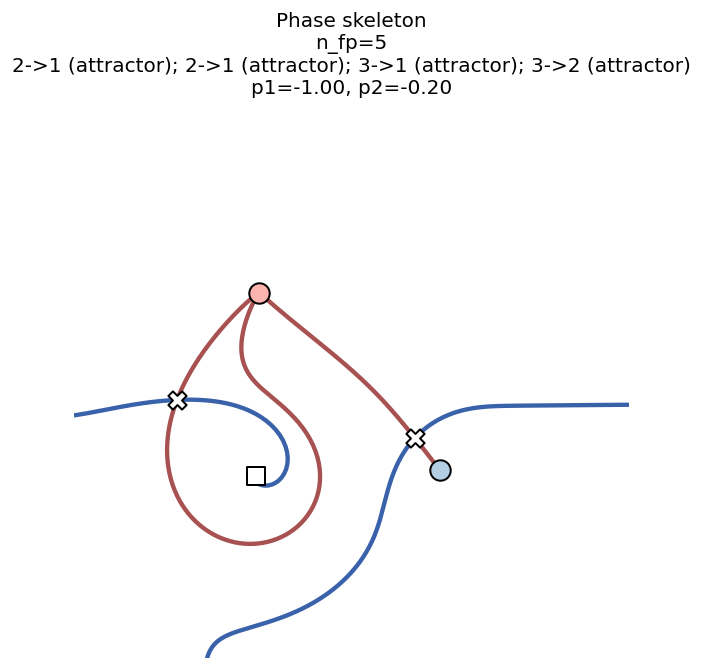

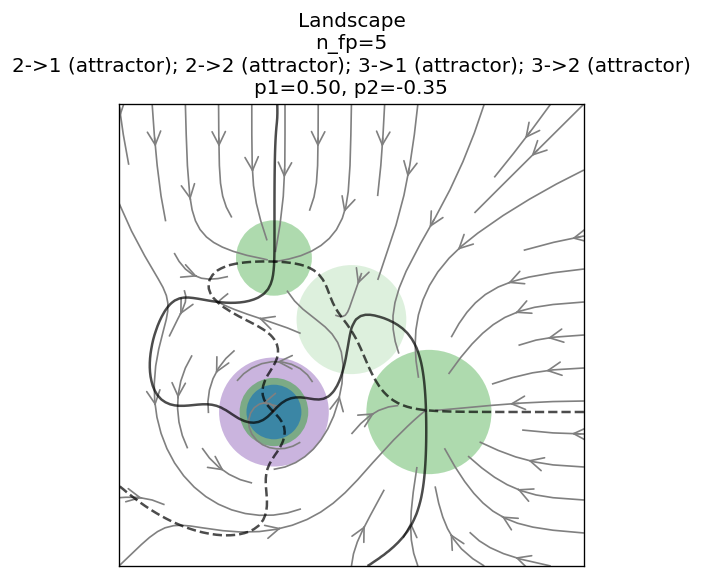

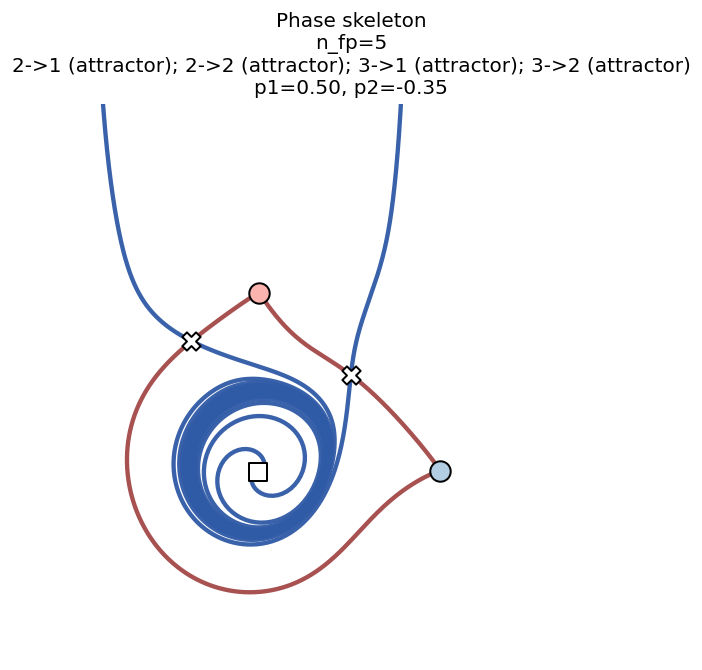

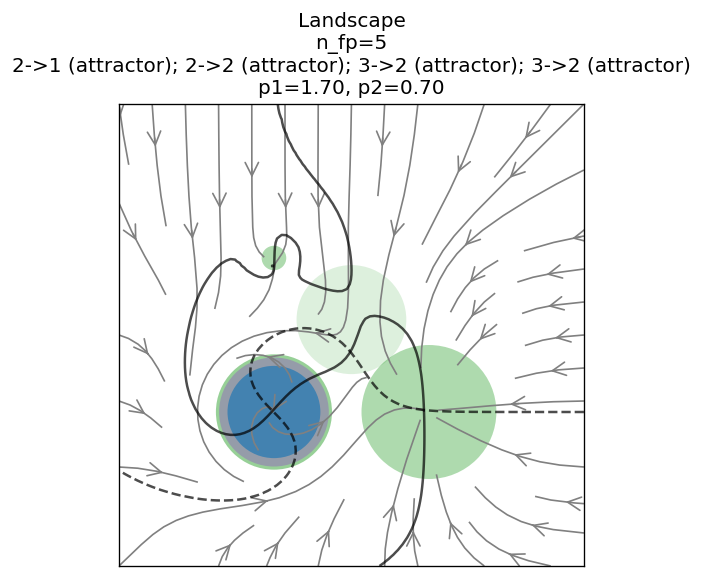

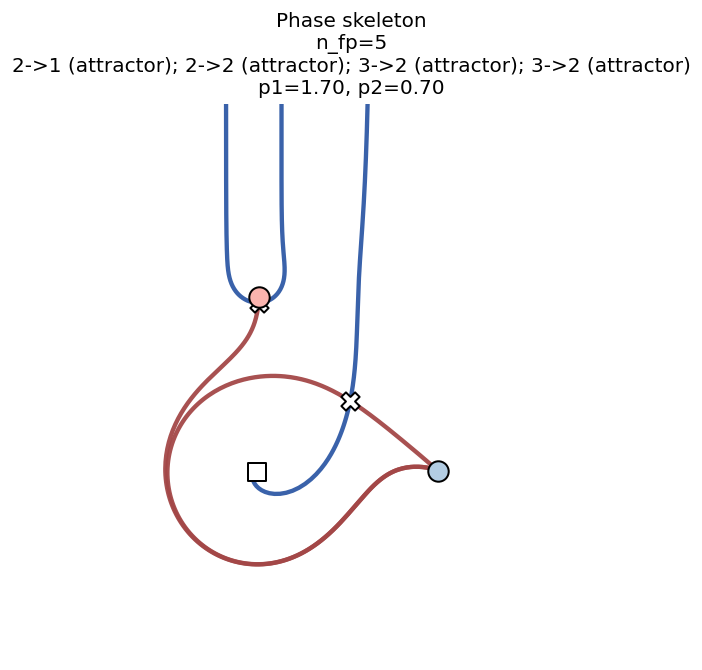

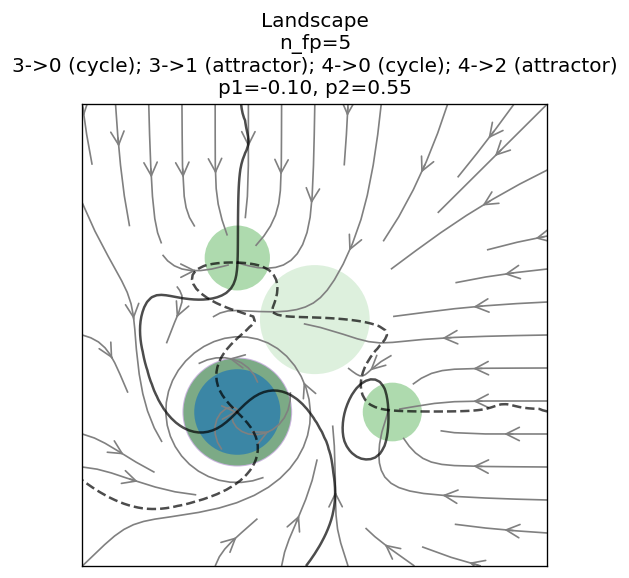

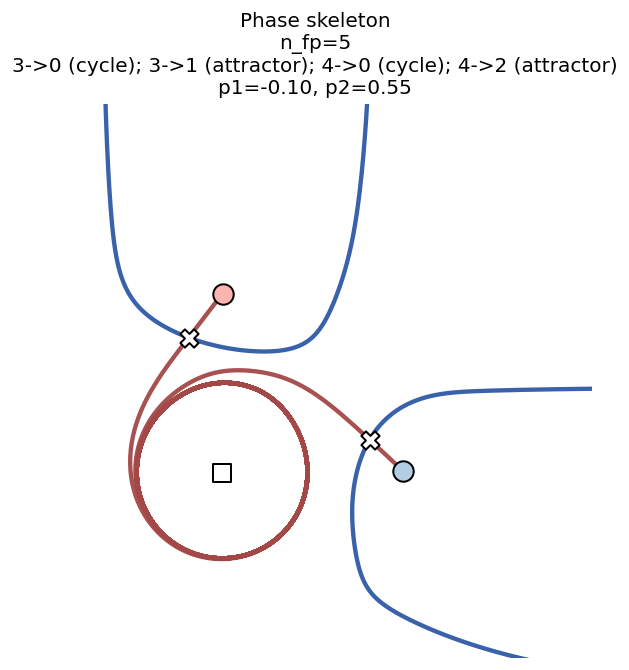

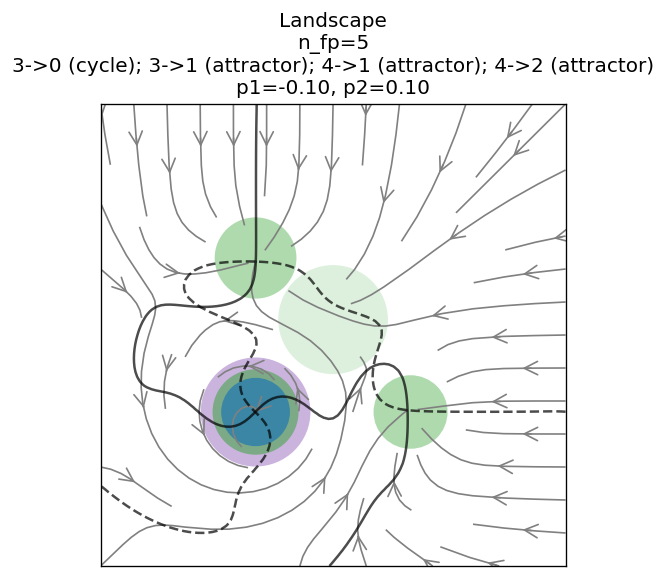

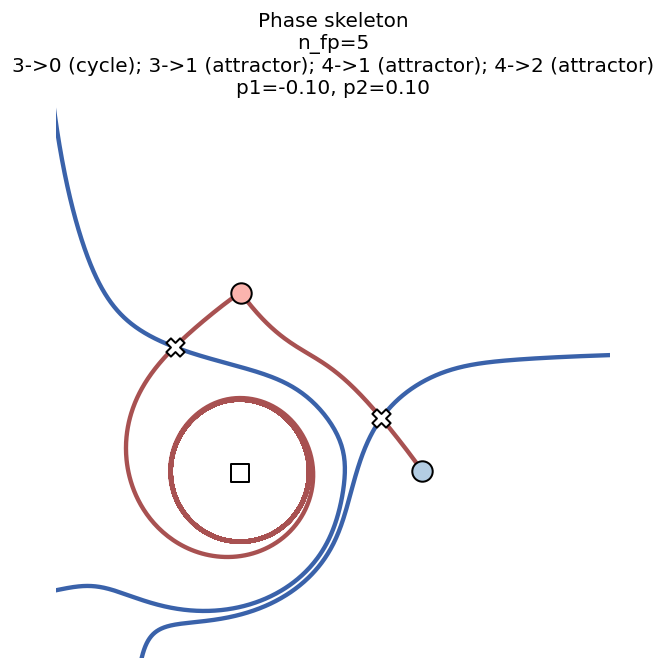

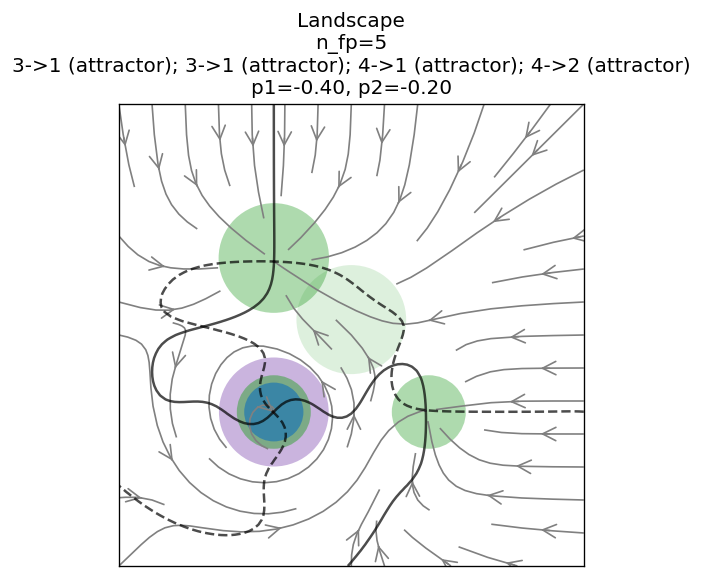

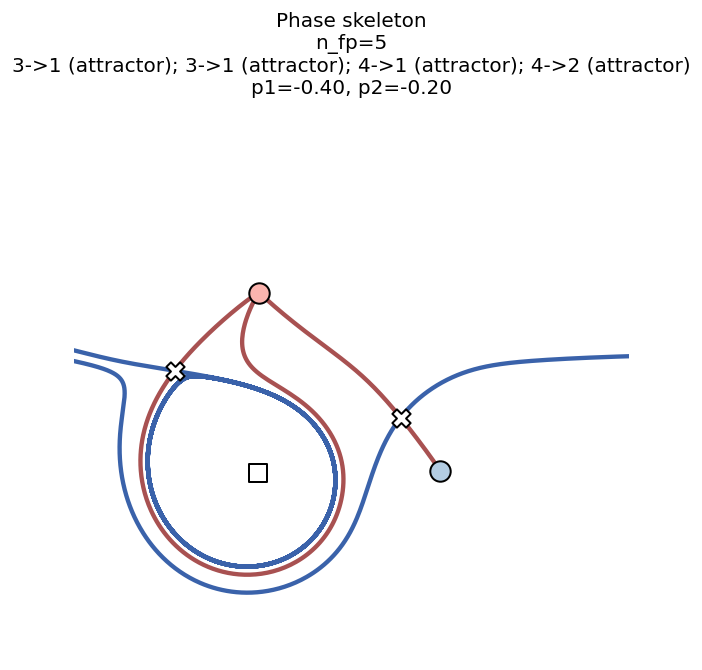

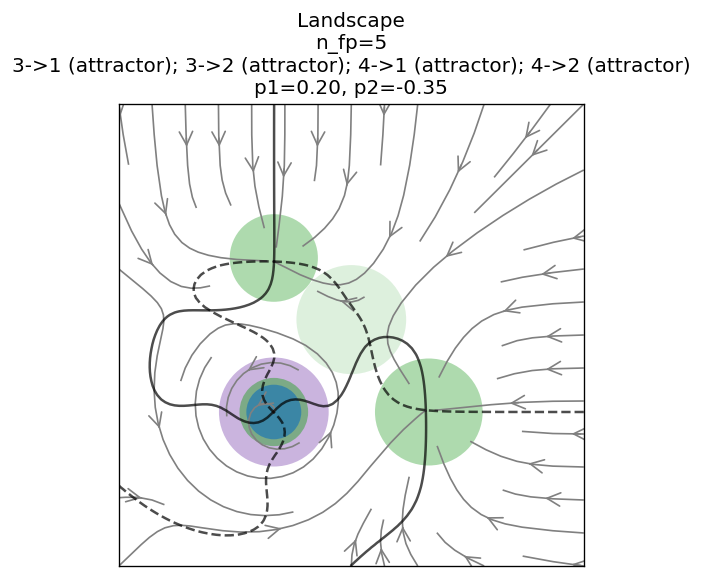

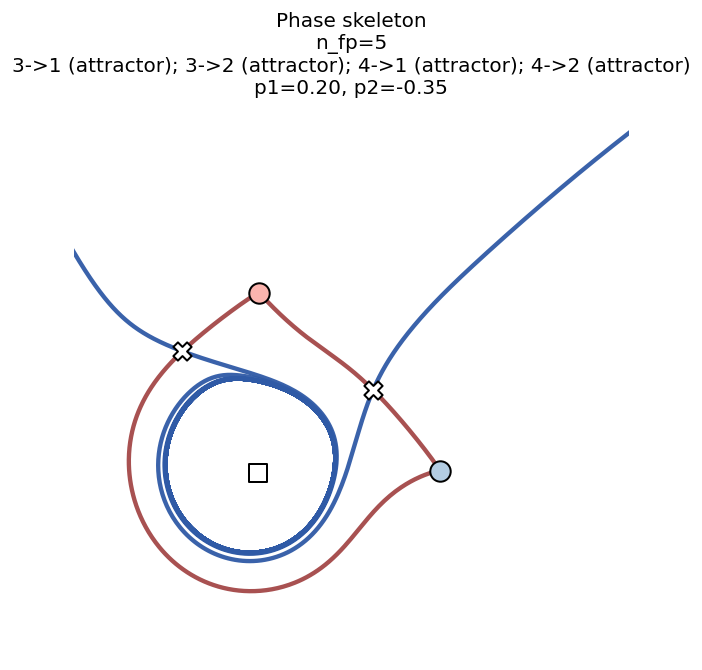

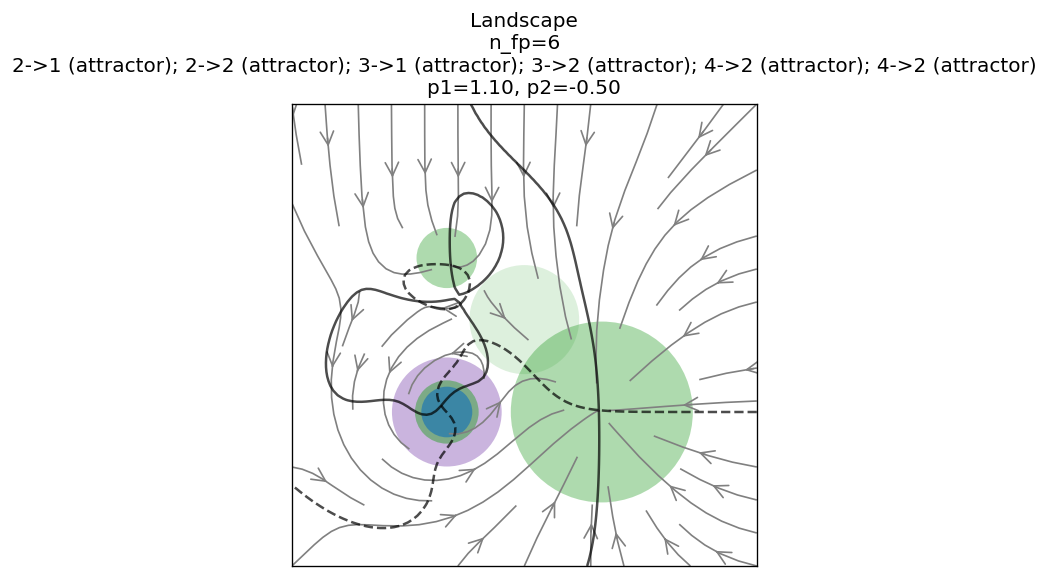

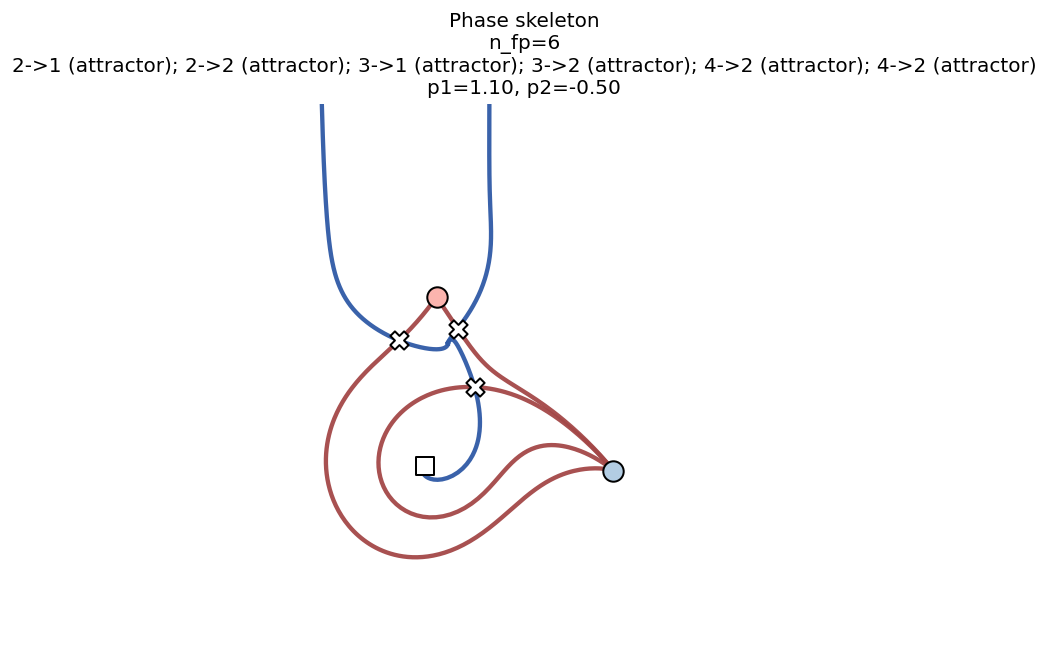

In [278]:
rng = np.random.default_rng(0)
sampled_regions = []
sample_figures = []

for key, indices in sorted(region_indices.items(), key=lambda item: (item[0][0], str(item[0][1]))):
    n_fp, signature = key
    sample_row, sample_col = indices[rng.integers(len(indices))]
    sample_p1 = p1[sample_col]
    sample_p2 = p2[sample_row]
    sampled_regions.append(
        {
            "n_fp": int(n_fp),
            "signature": signature,
            "p1": float(sample_p1),
            "p2": float(sample_p2),
            "n_cells": int(len(indices)),
        }
    )

    sample_landscape = update_landscape(sample_p1, sample_p2)
    sample_phase_result = sample_landscape.find_phase_objects_manifold(
        0.0,
        xx,
        yy,
        dt=0.1,
        n_steps=2000,
        cycle_window=0,
    )
    sample_landscape_fig = vis.visualize_landscape(
        sample_landscape,
        xx,
        yy,
        regime=0,
        color_scheme="fp_types",
    )
    sample_landscape_fig.axes[0].set_title(
        f"Landscape\nn_fp={n_fp}\n{signature_label(signature)}\np1={sample_p1:.2f}, p2={sample_p2:.2f}"
    )
    sample_skeleton_fig, sample_skeleton_ax, _ = vis.plot_phase_skeleton_t(
        sample_landscape,
        xx,
        yy,
        0.0,
        phase_result=sample_phase_result,
        show_saddle_manifolds=True,
    )
    sample_skeleton_ax.set_title(
        f"Phase skeleton\nn_fp={n_fp}\n{signature_label(signature)}\np1={sample_p1:.2f}, p2={sample_p2:.2f}"
    )
    sample_figures.append((sample_landscape_fig, sample_skeleton_fig))

sampled_regions

In [228]:
# region_id_grid = np.zeros((len(p2), len(p1)), dtype=int)
# region_keys = sorted(region_color_map, key=lambda key: (key[0], str(key[1])))
# region_id_map = {key: idx for idx, key in enumerate(region_keys)}
#
# for row_index in range(len(p2)):
#     for col_index in range(len(p1)):
#         catastrophe_info = catastrophe_info_grid[row_index, col_index]
#         key = (
#             int(catastrophe_info["n_fp"]),
#             unstable_connection_signature(catastrophe_info),
#         )
#         region_id_grid[row_index, col_index] = region_id_map[key]

In [279]:
# dp1 = p1[1] - p1[0]
# dp2 = p2[1] - p2[0]
# extent = (
#     p1[0] - 0.5 * dp1,
#     p1[-1] + 0.5 * dp1,
#     p2[0] - 0.5 * dp2,
#     p2[-1] + 0.5 * dp2,
# )
#
# fig = plt.figure(figsize=(6.4, 5.2))
# ax = plt.gca()
# ax.imshow(rgba_grid, origin="lower", extent=extent, interpolation="nearest", aspect="equal")
# ax.set_xlabel("p1")
# ax.set_ylabel("p2")
#
# #
# # fig = plt.figure(figsize=(6.4, 5.2))
# # ax = plt.gca()
#
# # for key, region_id in region_id_map.items():
# #     mask = np.where(region_id_grid == region_id, 1.0, 0.0)
# #     ax.contour(
# #         P1,
# #         P2,
# #         mask,
# #         levels=[0.5],
# #         colors=['k'],
# #         linewidths=2.0,
# #     )
# #
# # ax.set_xlabel("p1")
# # ax.set_ylabel("p2")
#
#
#
# for sample in sampled_regions:
#     ax.scatter(
#         sample["p1"],
#         sample["p2"],
#         s=42,
#         facecolors="white",
#         edgecolors="black",
#         linewidths=1.0,
#         zorder=3,
#     )
#
# legend_handles = [
#     Patch(facecolor=base_colors[int(n_fp)], edgecolor="none", label=f"n_fp = {int(n_fp)}")
#     for n_fp in unique_n_fp
# ]
# plt.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0))
# # plt.legend()
# # ax.add_artist(legend)
# # ax.text(
# #     1.02,
# #     0.62,
# #     " ",
# #     transform=ax.transAxes,
# #     ha="left",
# #     va="top",
# # )
# # fig.tight_layout()
# ax.set_aspect(2)
# plt.show()

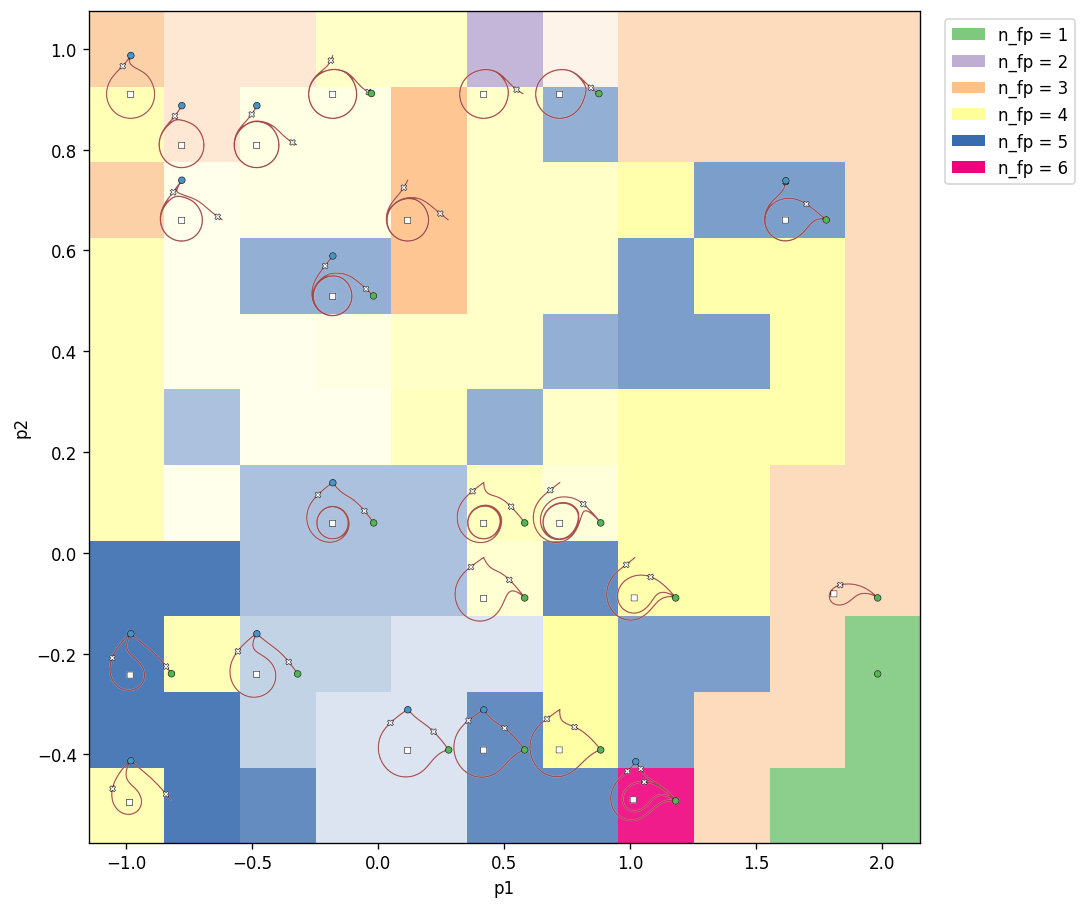

In [280]:
from io import BytesIO
from matplotlib.patches import Patch
%autoreload

order_colors = [
    "tab:purple",
    "tab:blue",
    "tab:green",
    "gold",
]

def render_skeleton_thumb(p1_value, p2_value):
    landscape = update_landscape(p1_value, p2_value)
    phase_result = landscape.find_phase_objects_manifold(
        0.0,
        xx,
        yy,
        dt=0.1,
        n_steps=2000,
        cycle_window=0,
    )
    fig_skel, ax_skel, _ = vis.plot_phase_skeleton_t(
        landscape,
        xx,
        yy,
        0.0,
        phase_result=phase_result,
        show_saddle_manifolds=True,
        plot_stable_manifolds=False,
        basin_coloring="node",
        module_order_colors=order_colors,
    )
    fig_skel.set_size_inches(4, 4)
    fig_skel.patch.set_alpha(0.0)
    ax_skel.set_facecolor((1, 1, 1, 0))

    buf = BytesIO()
    fig_skel.savefig(
        buf,
        format="png",
        dpi=180,
        bbox_inches="tight",
        pad_inches=0.0,
        transparent=True,
    )
    plt.close(fig_skel)
    buf.seek(0)
    image = plt.imread(buf)
    buf.close()
    return image


dp1 = p1[1] - p1[0]
dp2 = p2[1] - p2[0]
extent = (
    p1[0] - 0.5 * dp1,
    p1[-1] + 0.5 * dp1,
    p2[0] - 0.5 * dp2,
    p2[-1] + 0.5 * dp2,
)

fig = plt.figure(figsize=(9, 9))
ax = plt.gca()
ax.imshow(rgba_grid, origin="lower", extent=extent, interpolation="nearest", aspect="equal", alpha=0.9)
ax.set_xlabel("p1")
ax.set_ylabel("p2")

thumb_size = 0.15
thumb_pad = 0.0
x0, x1, y0, y1 = extent
thumb_cache = {}

for sample in sampled_regions[:]:
    key = (sample["p1"], sample["p2"])
    if key not in thumb_cache:
        thumb_cache[key] = render_skeleton_thumb(*key)
    image = thumb_cache[key]

    u = (sample["p1"] - x0) / (x1 - x0)
    v = (sample["p2"] - y0) / (y1 - y0)
    left = np.clip(u - 0.5 * thumb_size, thumb_pad, 1.0 - thumb_size - thumb_pad)
    bottom = np.clip(v - 0.5 * thumb_size, thumb_pad, 1.0 - thumb_size - thumb_pad)

    inset = ax.inset_axes([left, bottom, thumb_size, thumb_size], transform=ax.transAxes, zorder=4)
    inset.imshow(image)
    inset.set_xticks([])
    inset.set_yticks([])
    inset.set_facecolor((1, 1, 1, 0))
    for spine in inset.spines.values():
        spine.set_visible(False)
        # spine.set_linewidth(0.8)
        # spine.set_edgecolor("black")

legend_handles = [
    Patch(facecolor=base_colors[int(n_fp)], edgecolor="none", label=f"n_fp = {int(n_fp)}")
    for n_fp in unique_n_fp
]
plt.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.set_aspect(2)
plt.show()


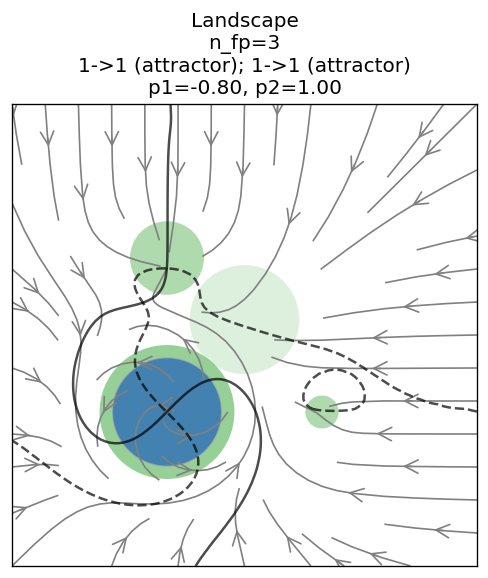

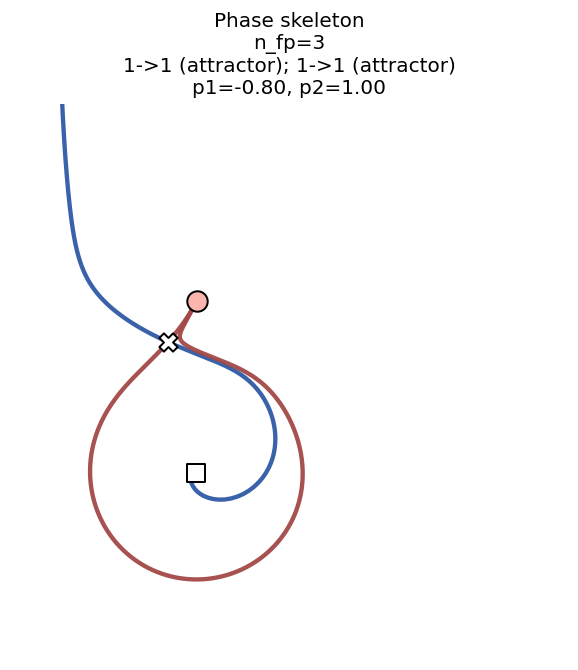

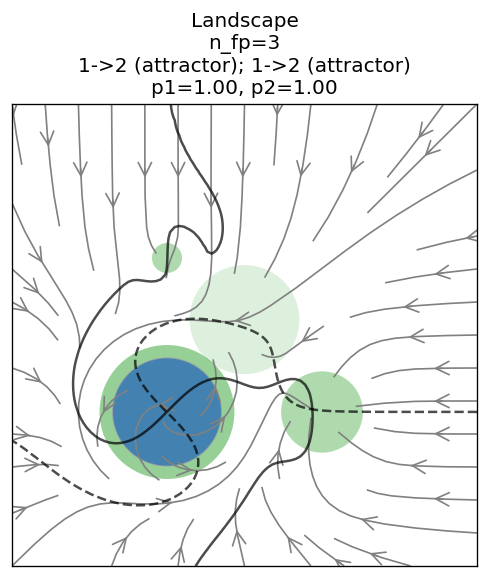

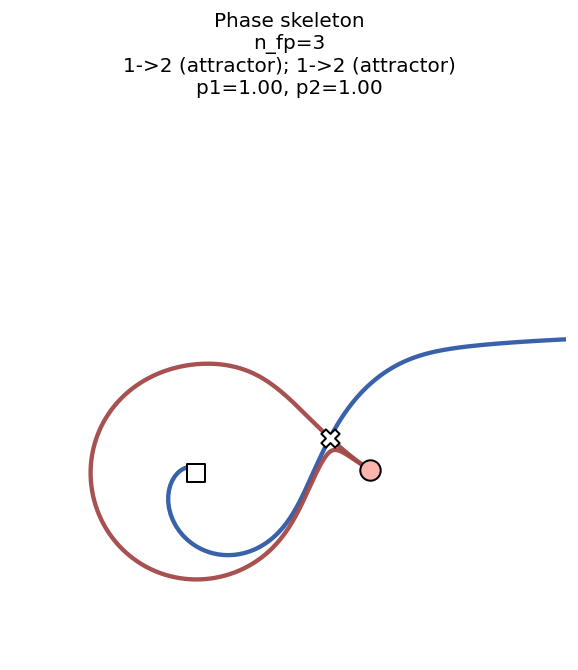

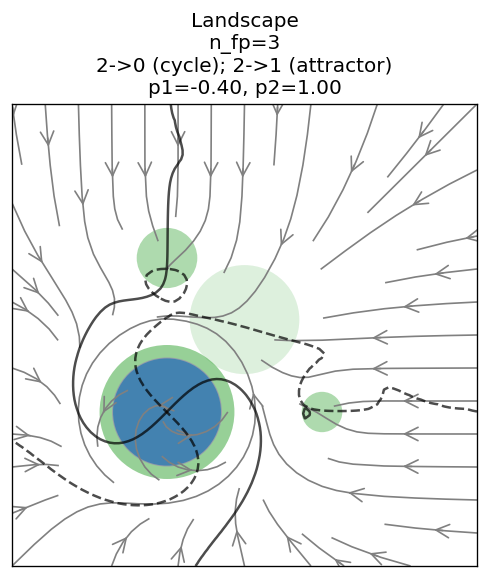

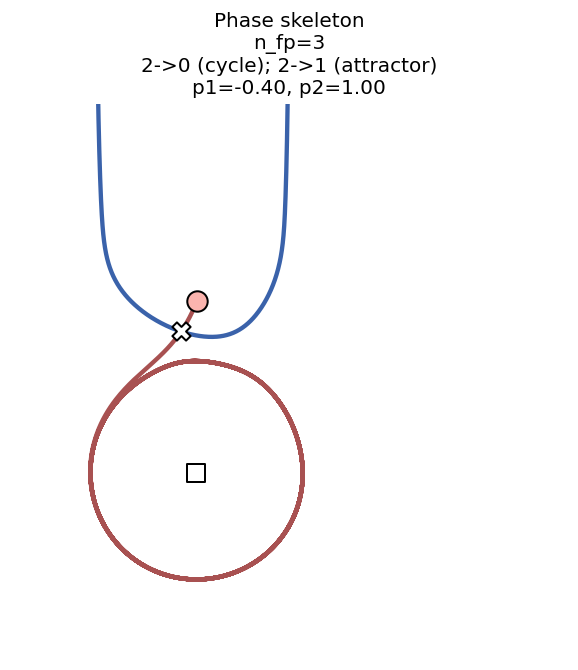

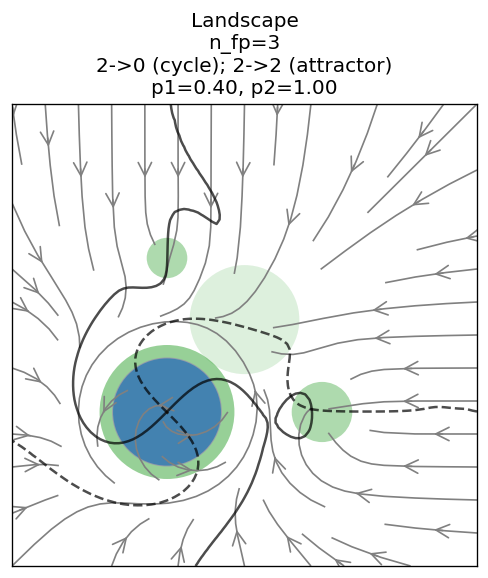

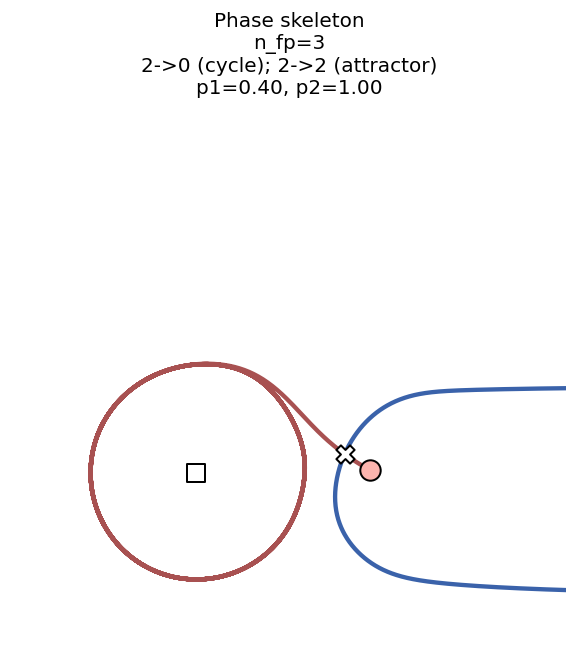

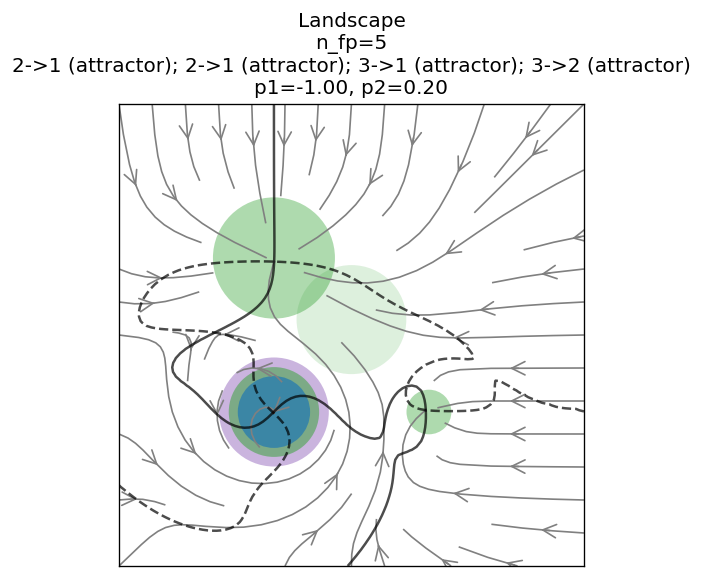

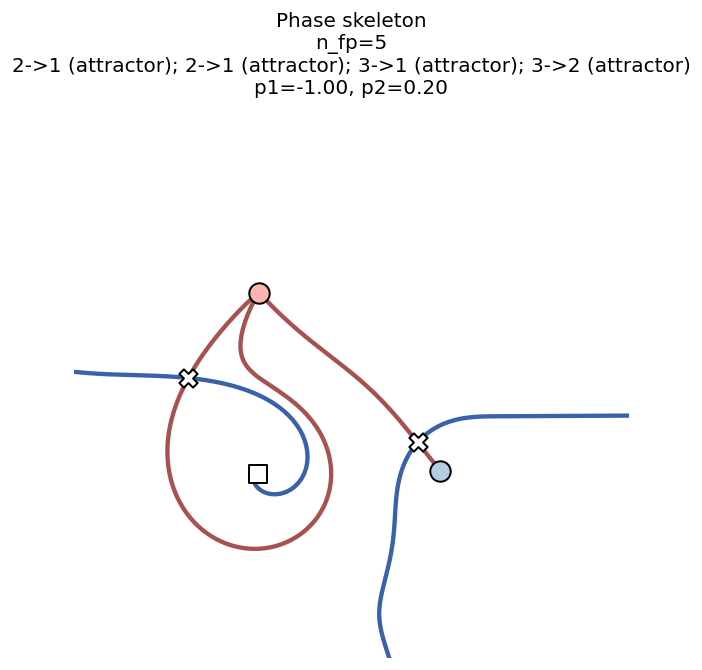

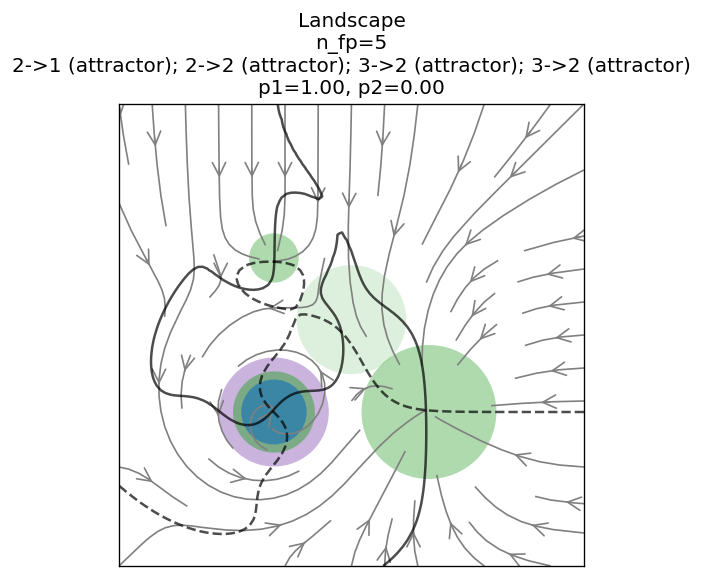

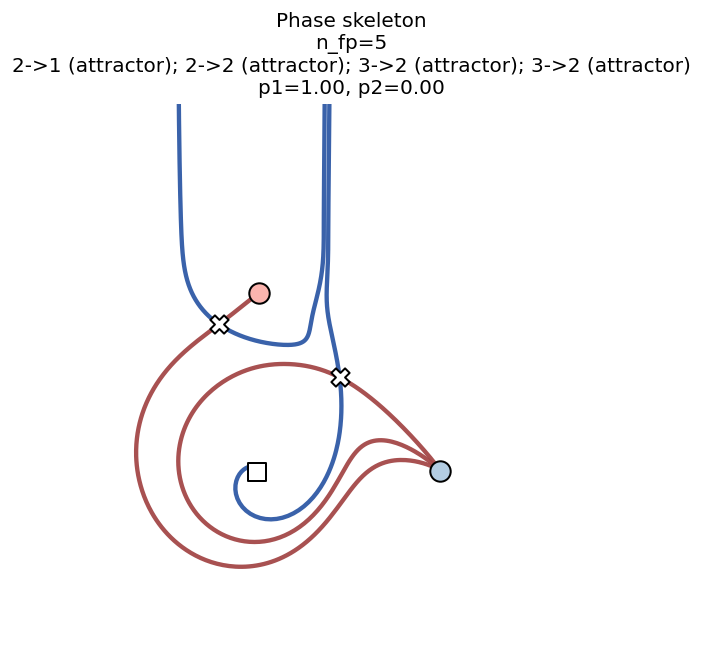

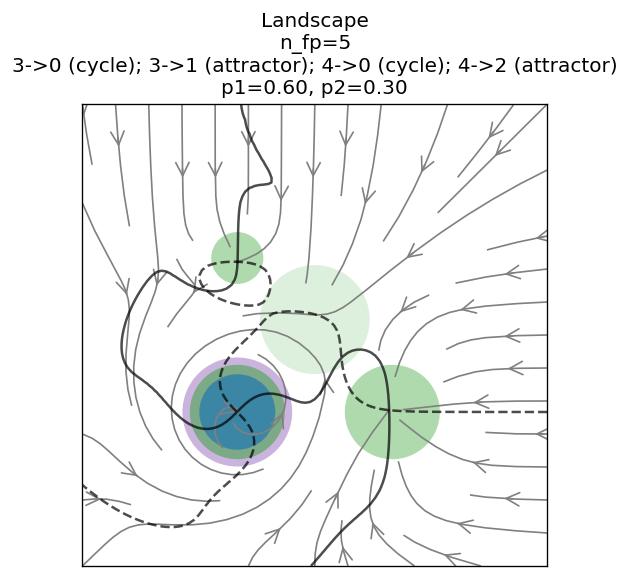

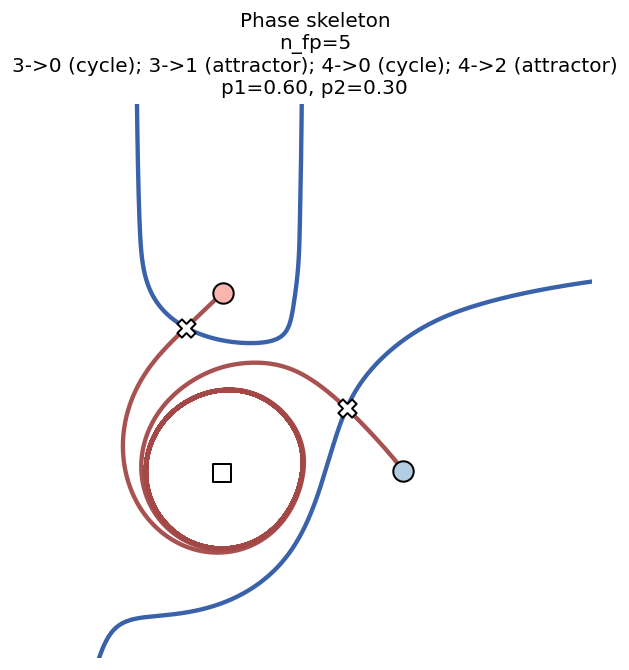

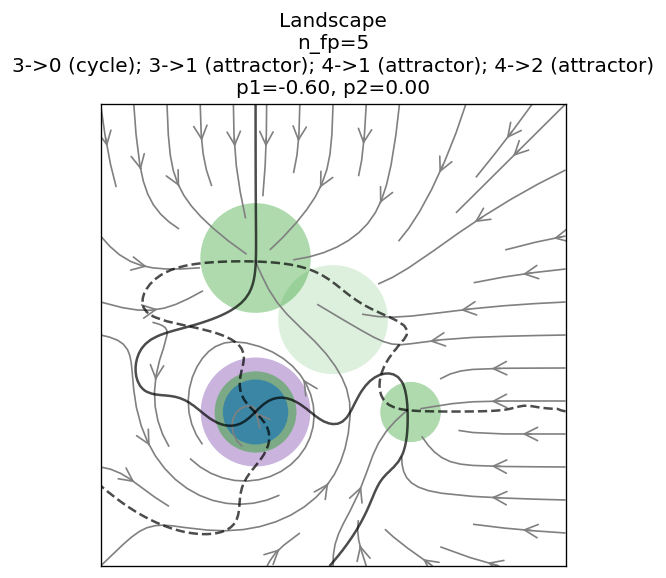

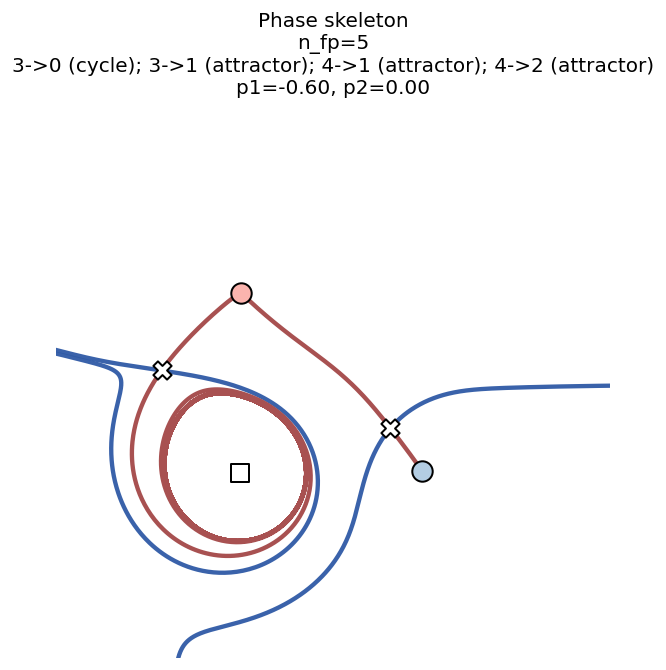

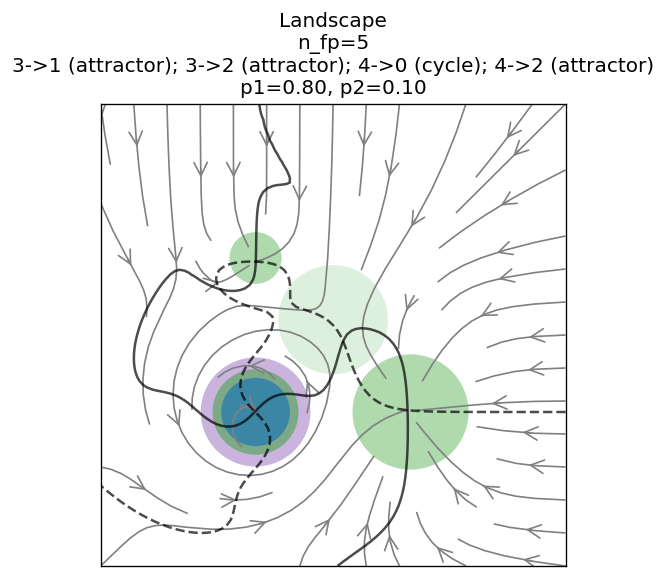

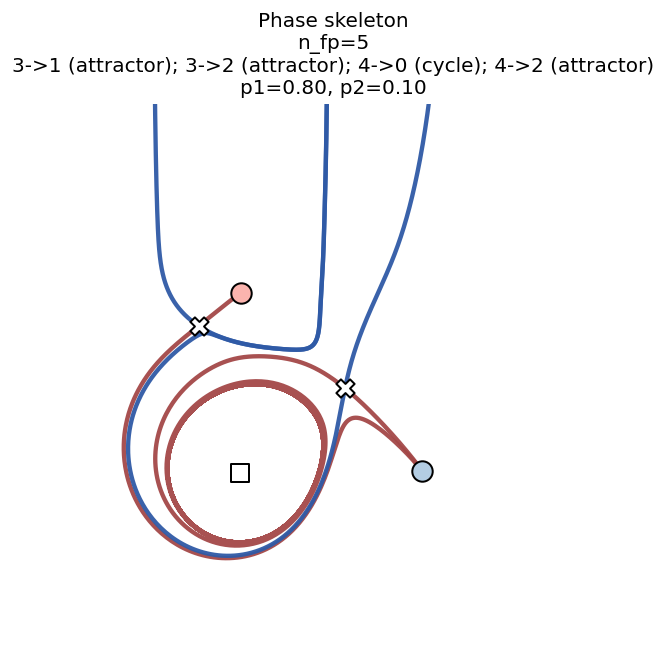

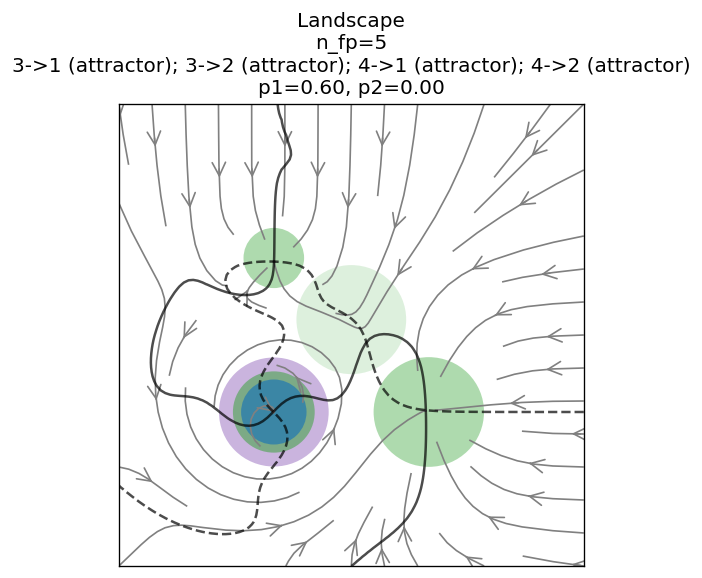

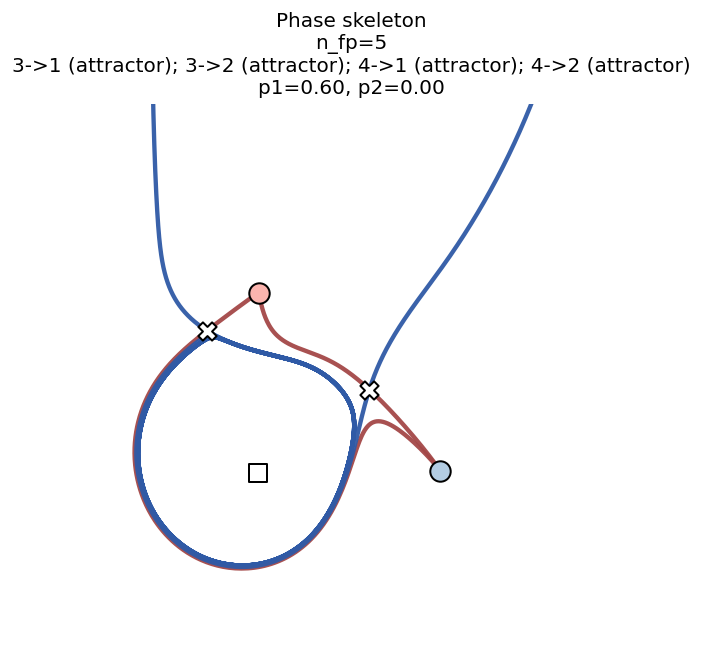

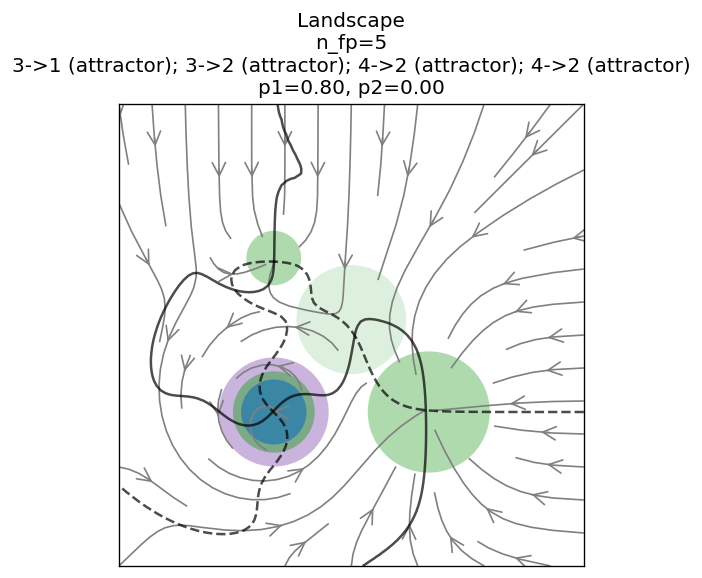

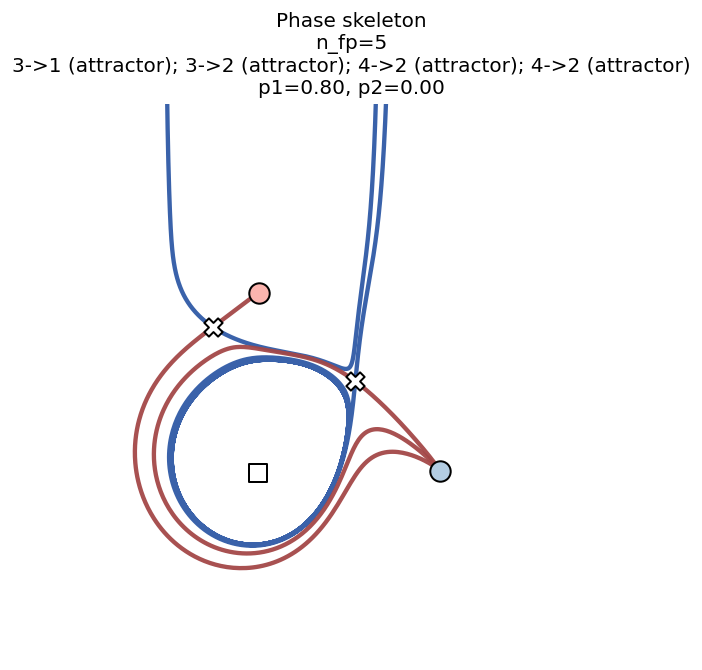

In [218]:
for landscape_fig, skeleton_fig in sample_figures:
    display(landscape_fig)
    display(skeleton_fig)